In [1]:
# --- Reset Jupyter widget state to prevent rendering errors ---
from IPython.display import display, HTML
import json

# Try to clean metadata if possible
try:
    import nbformat

    with open(__file__.replace('.py', '.ipynb'), "r+", encoding="utf-8") as f:
        nb = nbformat.read(f, as_version=4)
        for cell in nb["cells"]:
            if "metadata" in cell and "widgets" in cell["metadata"]:
                cell["metadata"].pop("widgets", None)
        f.seek(0)
        nbformat.write(nb, f)
        f.truncate()
except Exception as e:
    display(HTML(f"<b style='color:red'>Notebook metadata cleaned in memory (restart kernel if needed)</b>"))


In [2]:
pip install nbstripout

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!nbstripout "C:\Users\della\Downloads\Two-Product with Downward Substitution, static policy_+.ipynb"

In [ ]:
# # --- Reset Jupyter widget state to prevent rendering errors ---
# from IPython.display import display, HTML
# import json

# # Try to clean metadata if possible
# try:
#     import nbformat

#     with open(__file__.replace('.py', '.ipynb'), "r+", encoding="utf-8") as f:
#         nb = nbformat.read(f, as_version=4)
#         for cell in nb["cells"]:
#             if "metadata" in cell and "widgets" in cell["metadata"]:
#                 cell["metadata"].pop("widgets", None)
#         f.seek(0)
#         nbformat.write(nb, f)
#         f.truncate()
# except Exception as e:
#     display(HTML(f"<b style='color:red'>Notebook metadata cleaned in memory (restart kernel if needed)</b>"))


In [4]:
!pip install numpy-financial



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!pip install pandas


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install matplotlib
!pip install numpy


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import os
os.makedirs("./results", exist_ok=True)

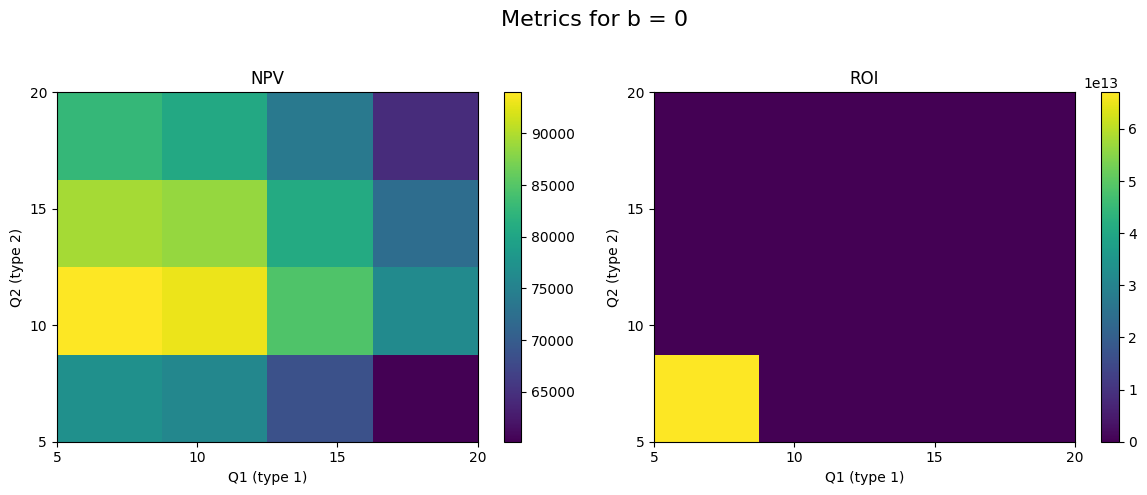

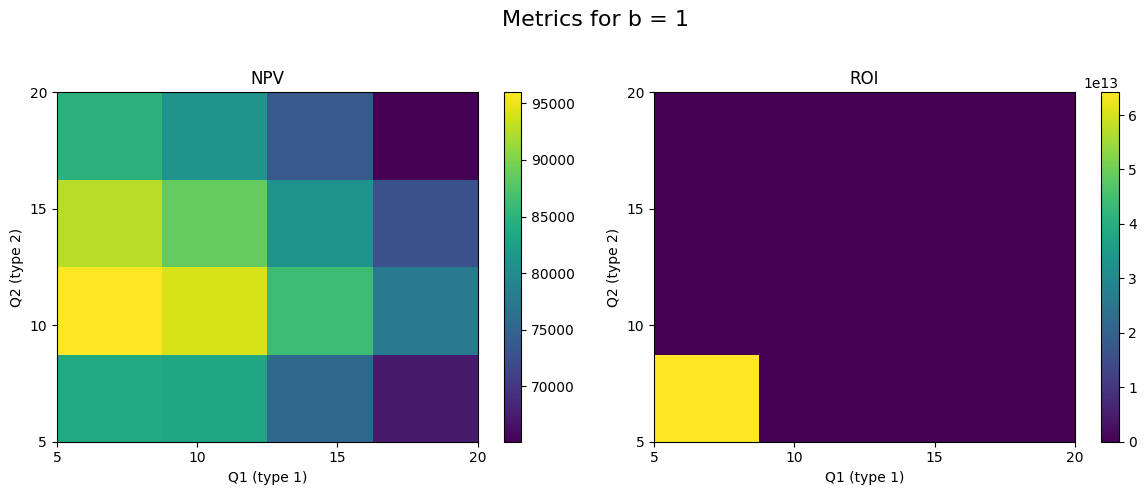

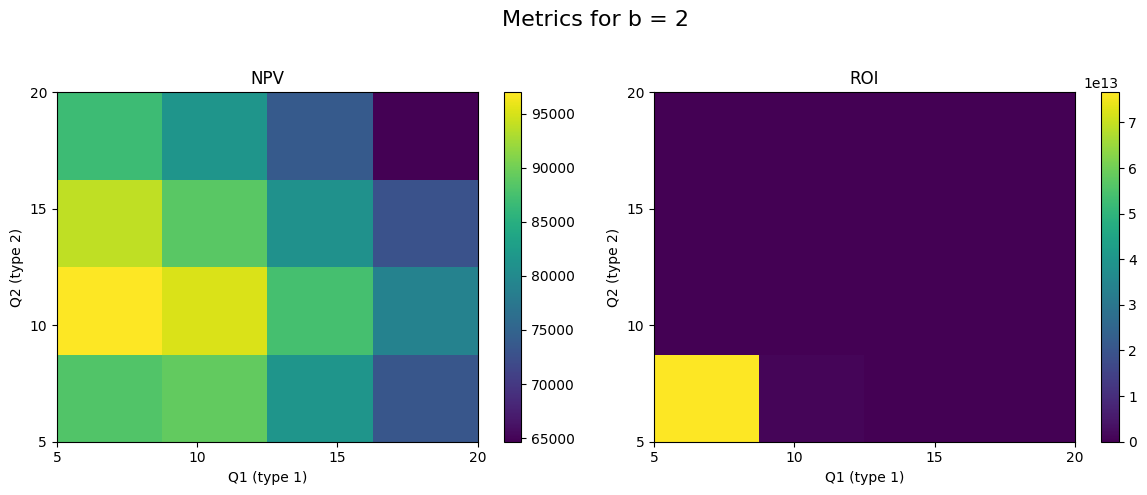

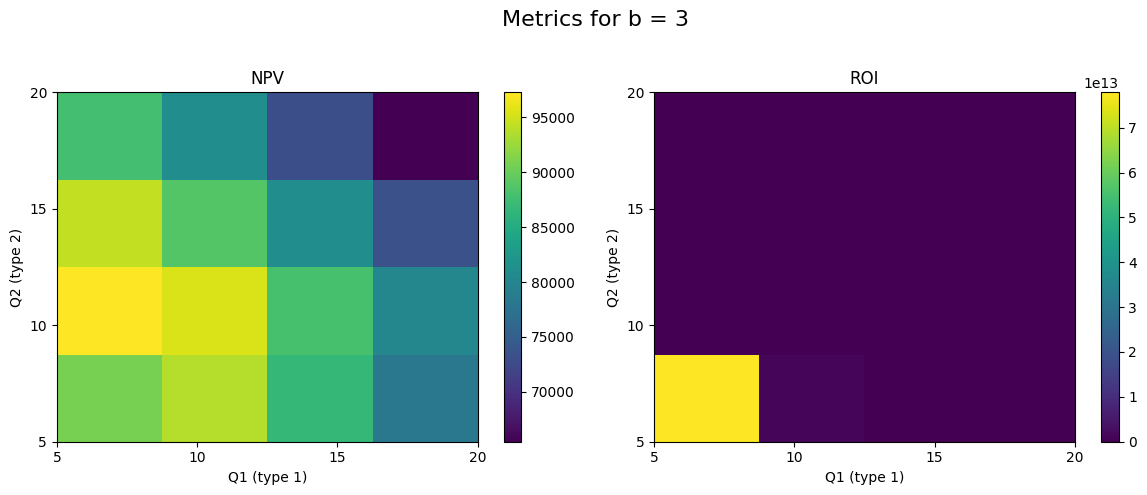

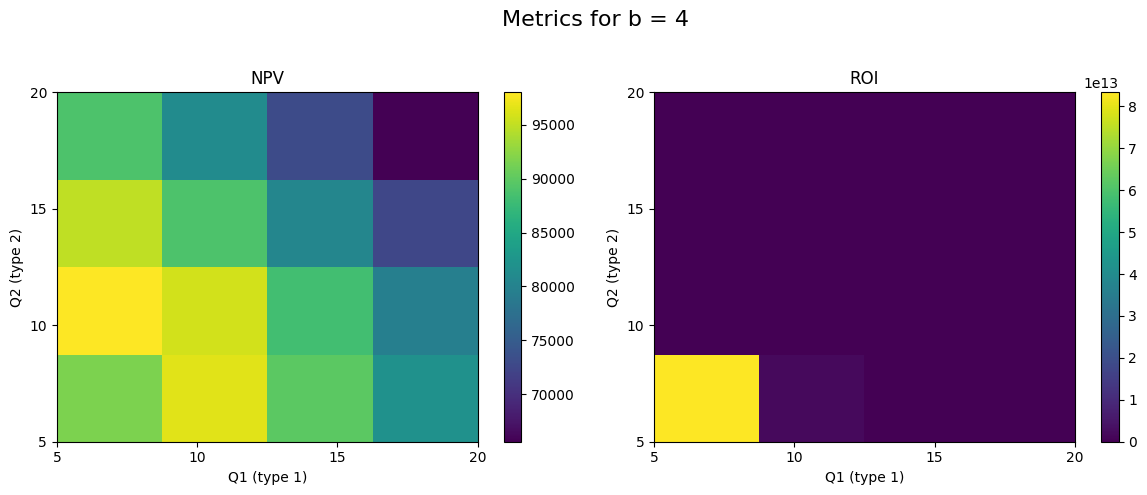

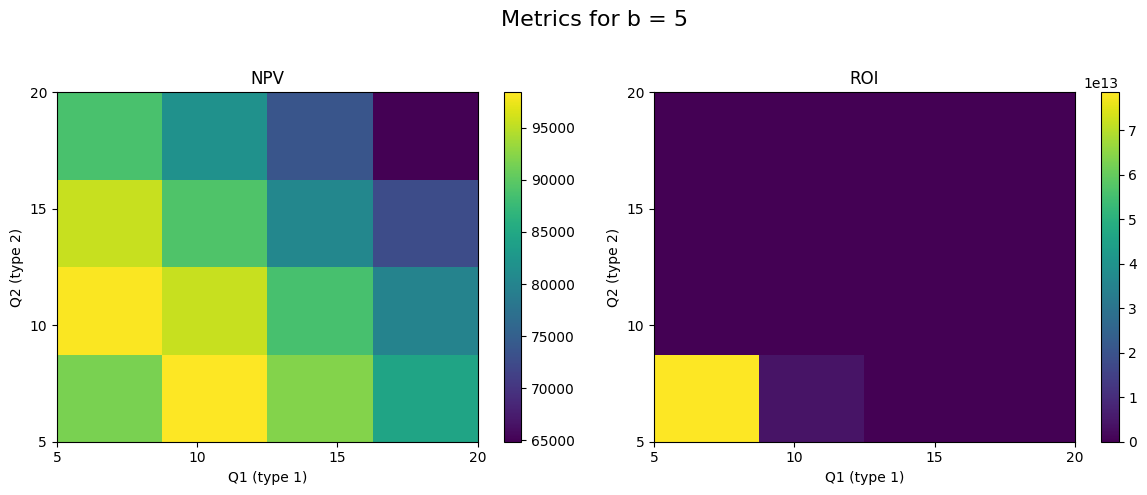

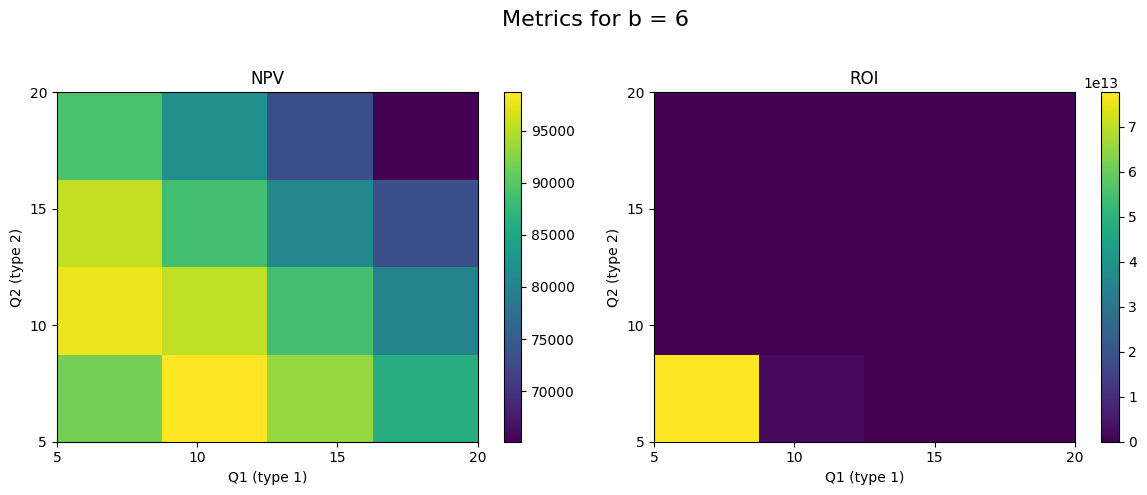

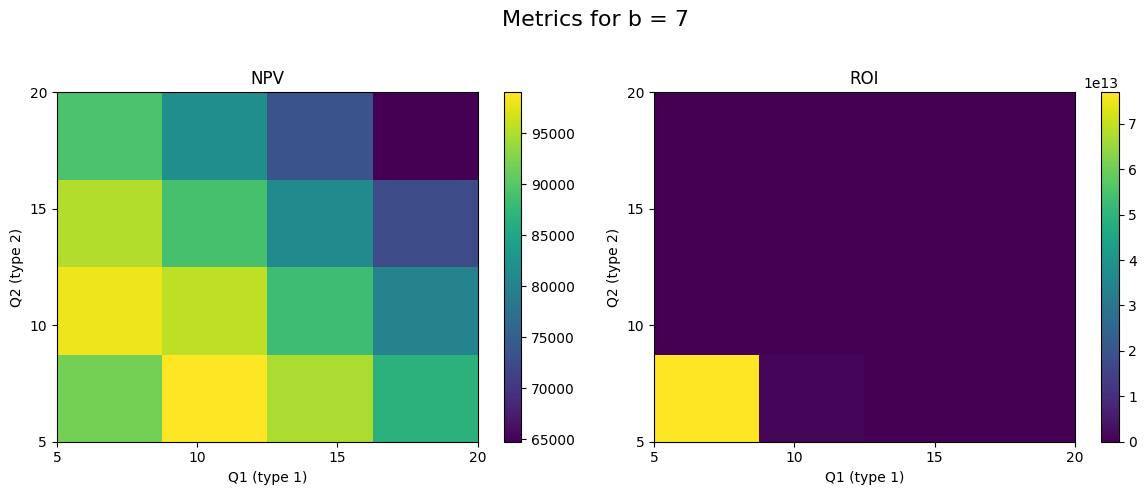

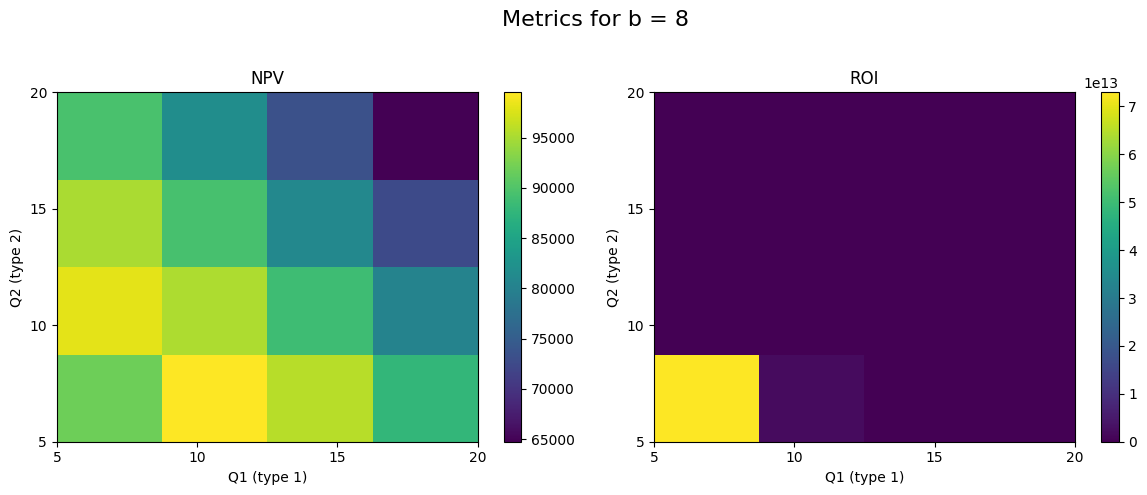

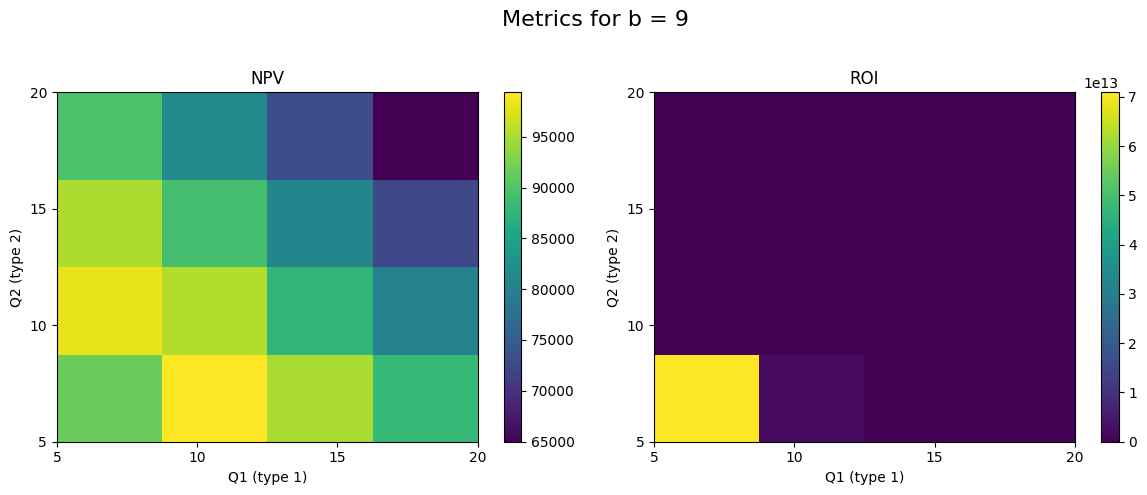

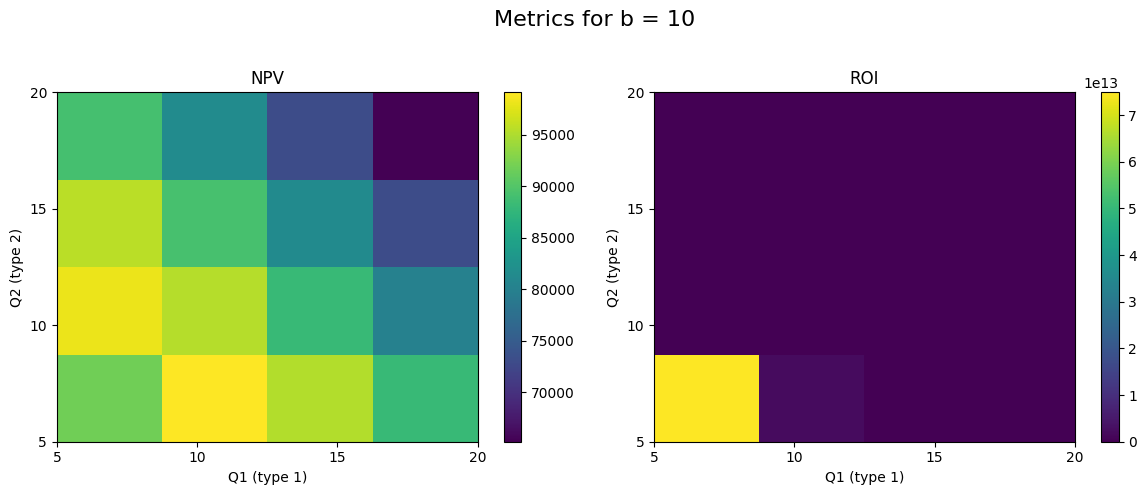

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Параметры модели
# ----------------------------
r_annual = 0.05
r_daily = (1 + r_annual) ** (1/365) - 1   # дневная ставка дисконтирования

T_days = 365  # горизонт симуляции = 1 год
#Nsim = 200    # число симуляций для Монте-Карло
#Nsim = 10    # число симуляций для Монте-Карло
Nsim = 100    # число симуляций для Монте-Карло

# спрос (кол-во клиентов в день ~ Пуассон)
LAMBDA1_daily = 10
LAMBDA2_daily = 8

# цены аренды
P1, P2 = 50.0, 25.0

# стоимость владения машиной в день
C1_daily = 10.0   # аренда/амортизация small
C2_daily = 15.0   # аренда/амортизация middle

# salvage-стоимость в конце года (как пример)
S1, S2 = 2000.0, 4000.0

# ----------------------------
# Функция симуляции
# ----------------------------
def simulate(Q1_init, Q2_init, b, seed=None):
    if seed is not None:
        np.random.seed(seed)

    Q1, Q2 = Q1_init, Q2_init

    cashflows = []

    for day in range(T_days):
        # ежедневные расходы на владение
        cost = -(Q1*C1_daily + Q2*C2_daily)

        # спрос
        #d1 = np.random.poisson(LAMBDA1_daily)
        d2 = np.random.poisson(LAMBDA2_daily)
        d1 = np.random.poisson(abs(d2 - 8) + 1)


        # аренда для класса 1
        rent1 = min(d1, Q1)
        d1_remain = d1 - rent1

        # аренда для класса 2
        rent2 = min(d2, Q2)
        d2_remain = d2 - rent2

        # замещения: клиенты 1 могут брать машину 2 (до b штук)
        subs12 = min(d1_remain, Q2 - rent2, b)

        # замещения: клиенты 2 могут брать машину 1 (до b штук)
        subs21 = min(d2_remain, Q1 - rent1, b)

        # выручка
        revenue = rent1*P1 + rent2*P2 + subs12*P1 + subs21*P2

        # дневной кэшфлоу
        cf = revenue + cost
        cashflows.append(cf)

    # salvage (в конце горизонта)
    salvage = Q1*S1 + Q2*S2
    cashflows[-1] += salvage

    # дисконтированные кэшфлоу
    npv = sum(cf / ((1+r_daily)**t) for t, cf in enumerate(cashflows, start=1))
    total_profit = sum(cashflows)

    # ROI и IRR (приближенно, т.к. нет явного CAPEX)
    roi = total_profit / abs(sum(cost for cost in cashflows if cost<0) + 1e-9)

    return {
        "NPV": npv,
        "Profit": total_profit,
        "ROI": roi
    }

# ----------------------------
# Гоняем для b от 0 до 20
# ----------------------------
results = []
Qmax = 20

for b in range(11):   # 0..10
    for Q1 in range(5, Qmax+1, 5):  # квантуем парк, чтобы меньше точек
        for Q2 in range(5, Qmax+1, 5):
            sims = [simulate(Q1, Q2, b) for _ in range(Nsim)]
            df = pd.DataFrame(sims)
            results.append({
                "b": b, "Q1": Q1, "Q2": Q2,
                "NPV": df["NPV"].mean(),
                "Profit": df["Profit"].mean(),
                "ROI": df["ROI"].mean()
            })

df_results = pd.DataFrame(results)

# ----------------------------
# Визуализация теплокарт
# ----------------------------
# metrics = ["NPV", "Profit", "ROI"]

# for metric in metrics:
#     fig, axes = plt.subplots(3, 4, figsize=(18, 12), constrained_layout=True)
#     axes = axes.ravel()

#     for b, ax in zip(range(11), axes):
#         pivot = df_results[df_results["b"]==b].pivot(index="Q2", columns="Q1", values=metric)
#         im = ax.imshow(pivot, origin="lower", cmap="viridis", aspect="auto")
#         ax.set_title(f"{metric}, b={b}")
#         ax.set_xlabel("Q1")
#         ax.set_ylabel("Q2")
#         fig.colorbar(im, ax=ax)

#     plt.suptitle(f"Heatmaps for {metric}", fontsize=18)
#     plt.show()
import matplotlib.pyplot as plt
import numpy as np

# строим теплокарты для каждого значения b
for b in df_results["b"].unique():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Metrics for b = {b}", fontsize=16)

    #for ax, metric in zip(axes.ravel(), ["NPV", "ROI", "Payback", "IRR"]):
    for ax, metric in zip(axes.ravel(), ["NPV", "ROI"]):
        pivot = df_results[df_results["b"]==b].pivot(index="Q2", columns="Q1", values=metric)

        # строим теплокарту с extent = реальные значения Q1/Q2
        im = ax.imshow(pivot.values, origin="lower", cmap="viridis", aspect="auto",
                       extent=[pivot.columns.min(), pivot.columns.max(),
                               pivot.index.min(), pivot.index.max()])

        ax.set_title(metric)
        ax.set_xlabel("Q1 (type 1)")
        ax.set_ylabel("Q2 (type 2)")

        # добавляем colorbar
        fig.colorbar(im, ax=ax)

        # ставим реальные метки Q1/Q2
        ax.set_xticks(pivot.columns)
        ax.set_yticks(pivot.index)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



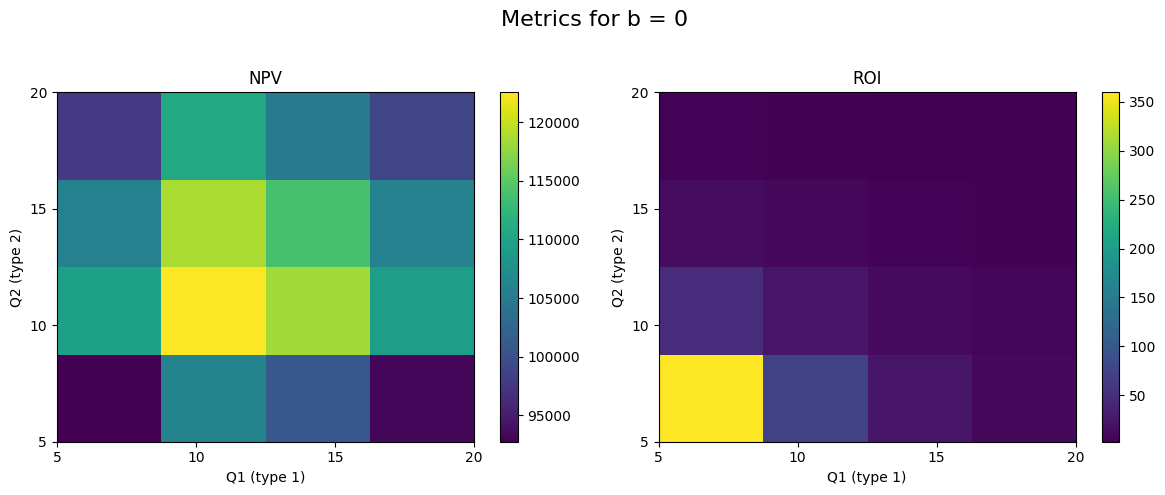

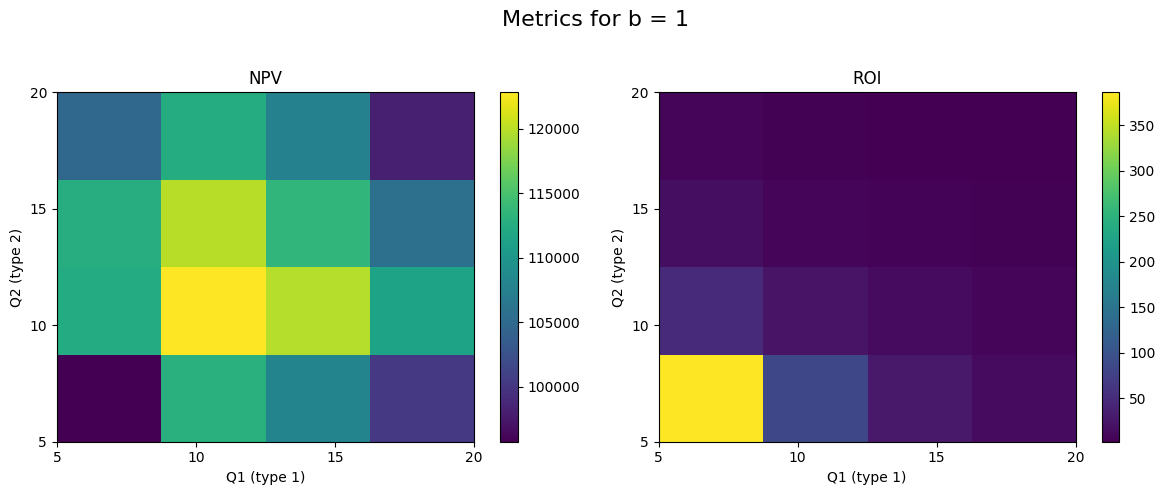

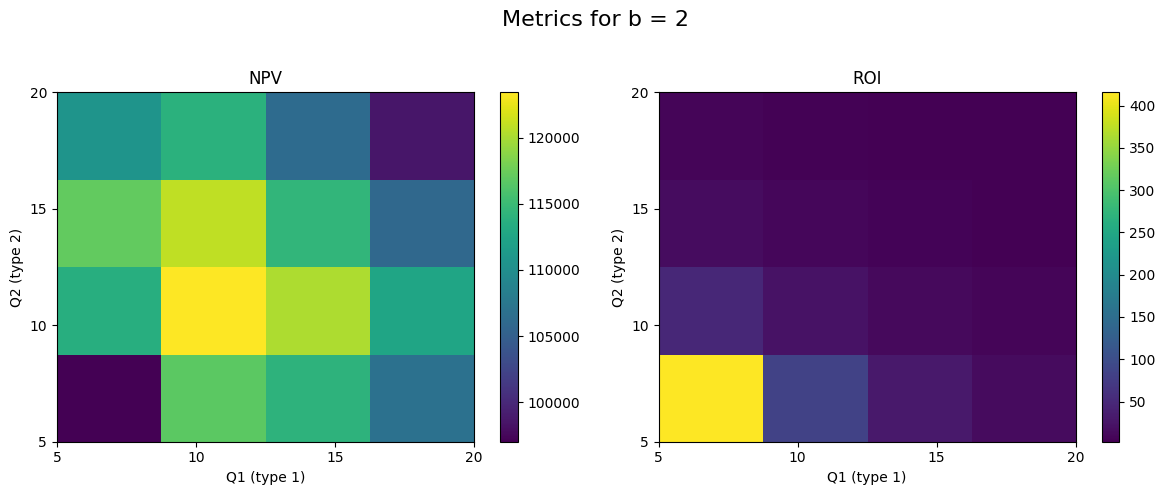

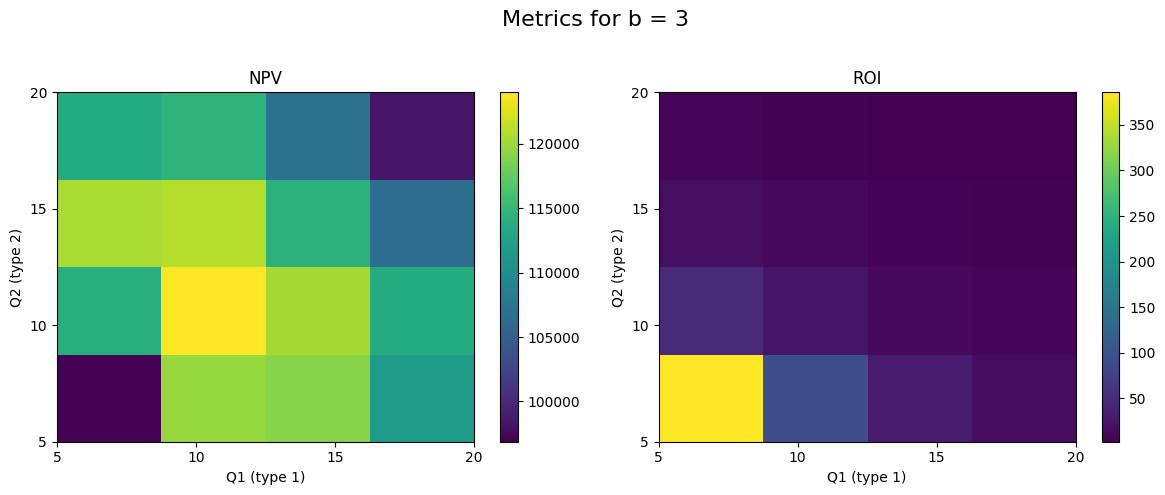

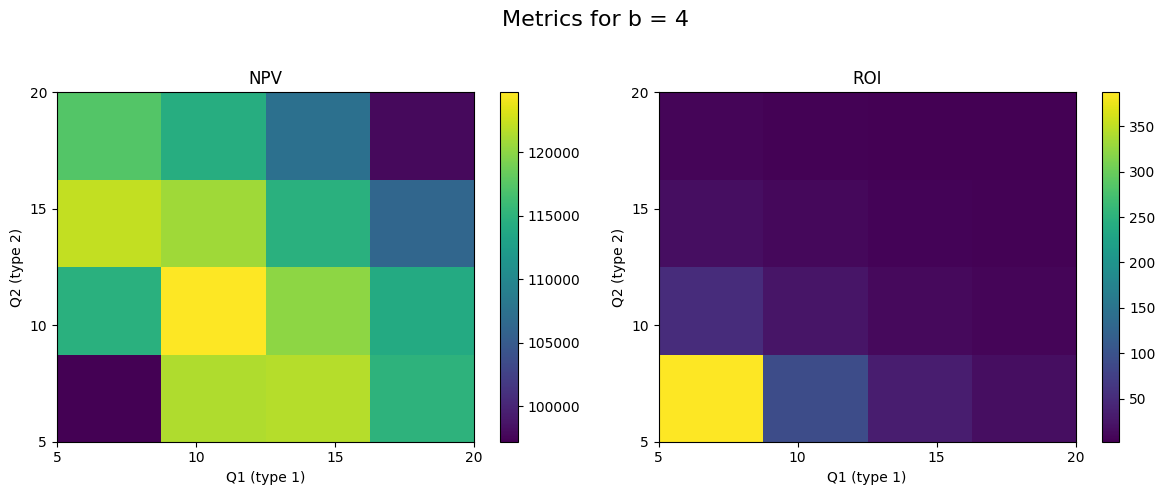

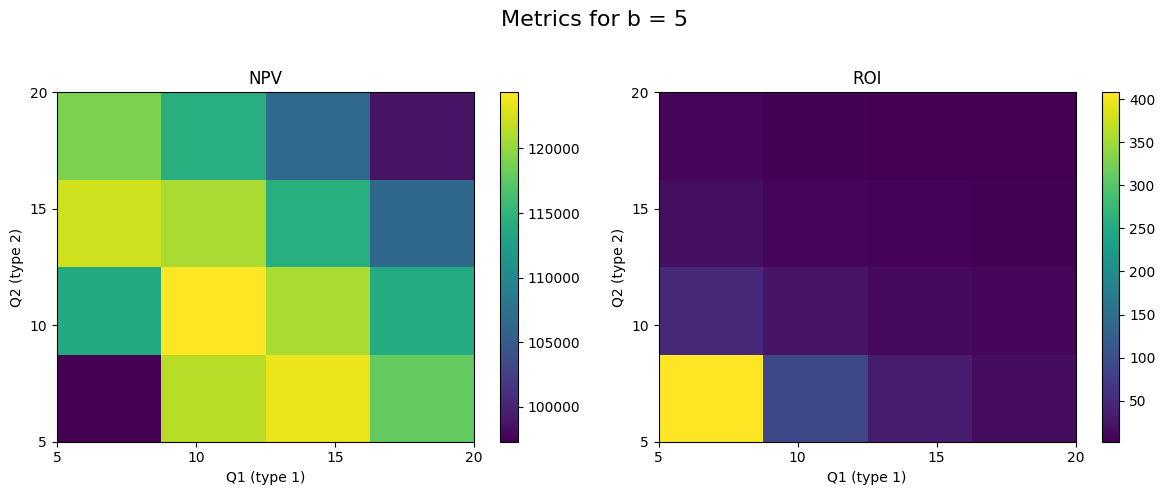

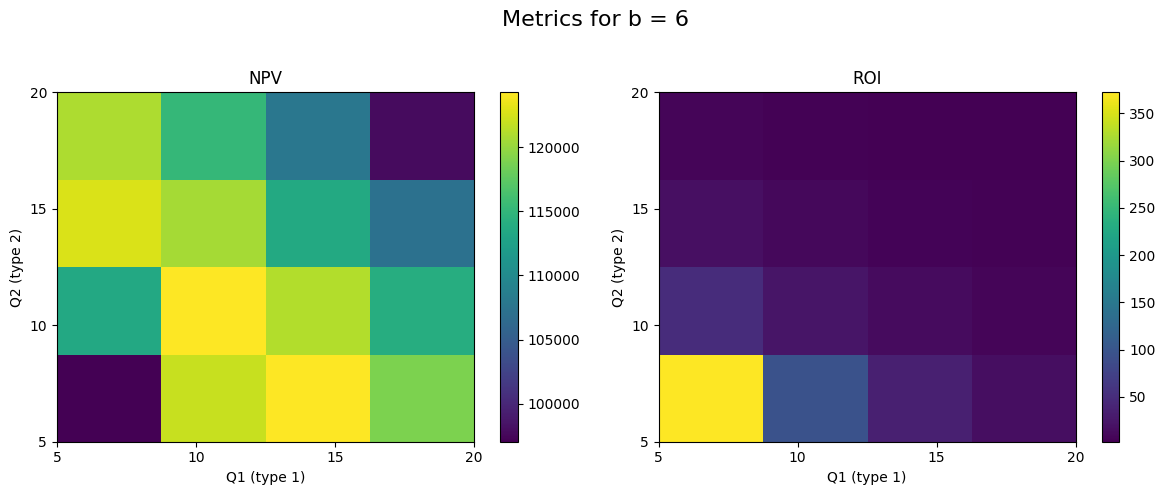

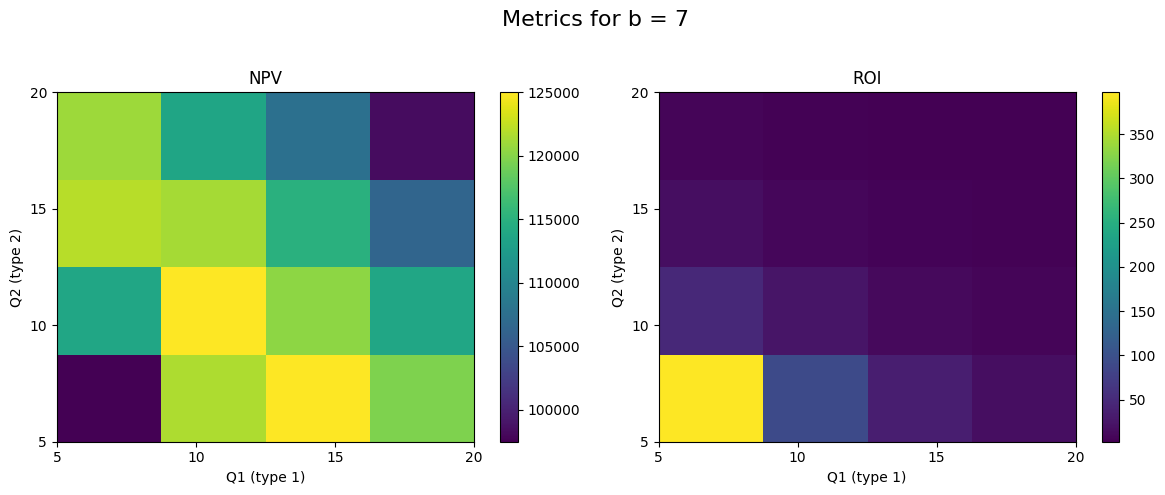

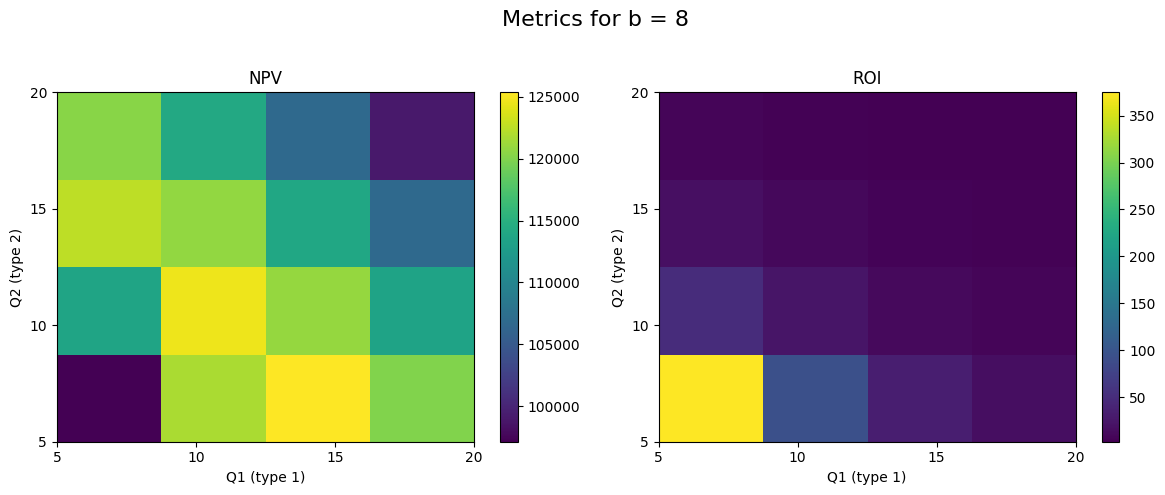

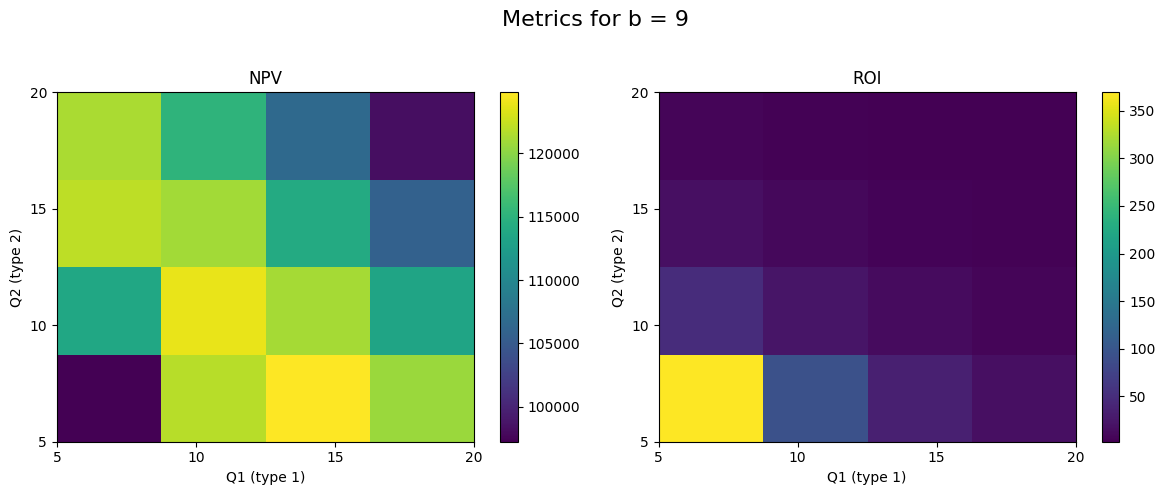

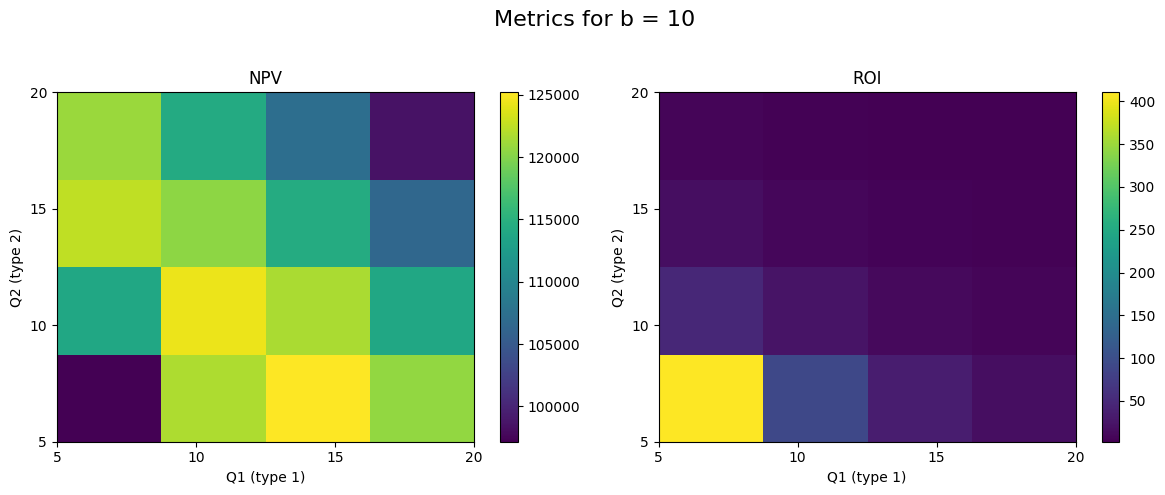

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Параметры модели
# ----------------------------
r_annual = 0.05
r_daily = (1 + r_annual) ** (1/365) - 1   # дневная ставка дисконтирования

T_days = 365  # горизонт симуляции = 1 год
#Nsim = 200    # число симуляций для Монте-Карло
#Nsim = 10    # число симуляций для Монте-Карло
Nsim = 100    # число симуляций для Монте-Карло

# спрос (кол-во клиентов в день ~ Пуассон)
LAMBDA1_daily = 10
LAMBDA2_daily = 8

# цены аренды
P1, P2 = 50.0, 25.0

# стоимость владения машиной в день
C1_daily = 10.0   # аренда/амортизация small
C2_daily = 15.0   # аренда/амортизация middle

# salvage-стоимость в конце года (как пример)
S1, S2 = 2000.0, 4000.0

# ----------------------------
# Функция симуляции
# ----------------------------
def simulate(Q1_init, Q2_init, b, seed=None):
    if seed is not None:
        np.random.seed(seed)

    Q1, Q2 = Q1_init, Q2_init

    cashflows = []

    for day in range(T_days):
        # ежедневные расходы на владение
        cost = -(Q1*C1_daily + Q2*C2_daily)

        # спрос
        m=4
        #d1 = np.random.poisson(LAMBDA1_daily)
        d2 = np.random.poisson(LAMBDA2_daily)
        d1 = np.random.poisson(abs(d2 - m) + 1)


        # аренда для класса 1
        rent1 = min(d1, Q1)
        d1_remain = d1 - rent1

        # аренда для класса 2
        rent2 = min(d2, Q2)
        d2_remain = d2 - rent2

        # замещения: клиенты 1 могут брать машину 2 (до b штук)
        subs12 = min(d1_remain, Q2 - rent2, b)

        # замещения: клиенты 2 могут брать машину 1 (до b штук)
        subs21 = min(d2_remain, Q1 - rent1, b)

        # выручка
        revenue = rent1*P1 + rent2*P2 + subs12*P1 + subs21*P2

        # дневной кэшфлоу
        cf = revenue + cost
        cashflows.append(cf)

    # salvage (в конце горизонта)
    salvage = Q1*S1 + Q2*S2
    cashflows[-1] += salvage

    # дисконтированные кэшфлоу
    npv = sum(cf / ((1+r_daily)**t) for t, cf in enumerate(cashflows, start=1))
    total_profit = sum(cashflows)

    # ROI и IRR (приближенно, т.к. нет явного CAPEX)
    roi = total_profit / abs(sum(cost for cost in cashflows if cost<0) + 1e-9)

    return {
        "NPV": npv,
        "Profit": total_profit,
        "ROI": roi
    }

# ----------------------------
# Гоняем для b от 0 до 10
# ----------------------------
results = []
Qmax = 20

for b in range(11):   # 0..10
    for Q1 in range(5, Qmax+1, 5):  # квантуем парк, чтобы меньше точек
        for Q2 in range(5, Qmax+1, 5):
            sims = [simulate(Q1, Q2, b) for _ in range(Nsim)]
            df = pd.DataFrame(sims)
            results.append({
                "b": b, "Q1": Q1, "Q2": Q2,
                "NPV": df["NPV"].mean(),
                "Profit": df["Profit"].mean(),
                "ROI": df["ROI"].mean()
            })

df_results = pd.DataFrame(results)

# ----------------------------
# Визуализация теплокарт
# ----------------------------
# metrics = ["NPV", "Profit", "ROI"]

# for metric in metrics:
#     fig, axes = plt.subplots(3, 4, figsize=(18, 12), constrained_layout=True)
#     axes = axes.ravel()

#     for b, ax in zip(range(11), axes):
#         pivot = df_results[df_results["b"]==b].pivot(index="Q2", columns="Q1", values=metric)
#         im = ax.imshow(pivot, origin="lower", cmap="viridis", aspect="auto")
#         ax.set_title(f"{metric}, b={b}")
#         ax.set_xlabel("Q1")
#         ax.set_ylabel("Q2")
#         fig.colorbar(im, ax=ax)

#     plt.suptitle(f"Heatmaps for {metric}", fontsize=18)
#     plt.show()
import matplotlib.pyplot as plt
import numpy as np

# строим теплокарты для каждого значения b
for b in df_results["b"].unique():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Metrics for b = {b}", fontsize=16)

    #for ax, metric in zip(axes.ravel(), ["NPV", "ROI", "Payback", "IRR"]):
    for ax, metric in zip(axes.ravel(), ["NPV", "ROI"]):
        pivot = df_results[df_results["b"]==b].pivot(index="Q2", columns="Q1", values=metric)

        # строим теплокарту с extent = реальные значения Q1/Q2
        im = ax.imshow(pivot.values, origin="lower", cmap="viridis", aspect="auto",
                       extent=[pivot.columns.min(), pivot.columns.max(),
                               pivot.index.min(), pivot.index.max()])

        ax.set_title(metric)
        ax.set_xlabel("Q1 (type 1)")
        ax.set_ylabel("Q2 (type 2)")

        # добавляем colorbar
        fig.colorbar(im, ax=ax)

        # ставим реальные метки Q1/Q2
        ax.set_xticks(pivot.columns)
        ax.set_yticks(pivot.index)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()



C:\Users\della\AppData\Local\Temp\ipykernel_57164\267859577.py:185: RuntimeWarning: Mean of empty slice
  results.append([Q1, Q2, np.mean(npvs), np.mean(rois), np.nanmean(pays), np.nanmean(irrs)])


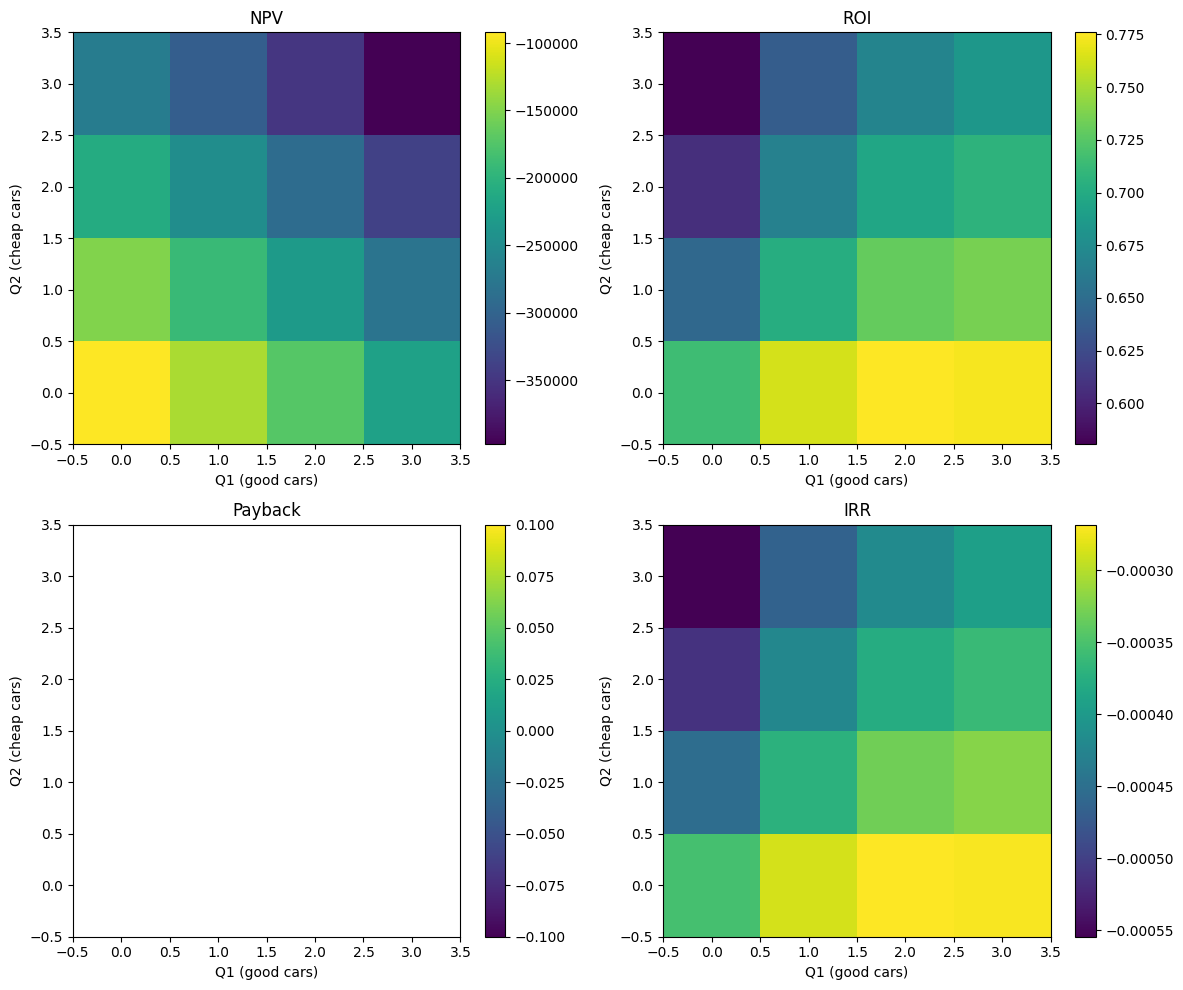

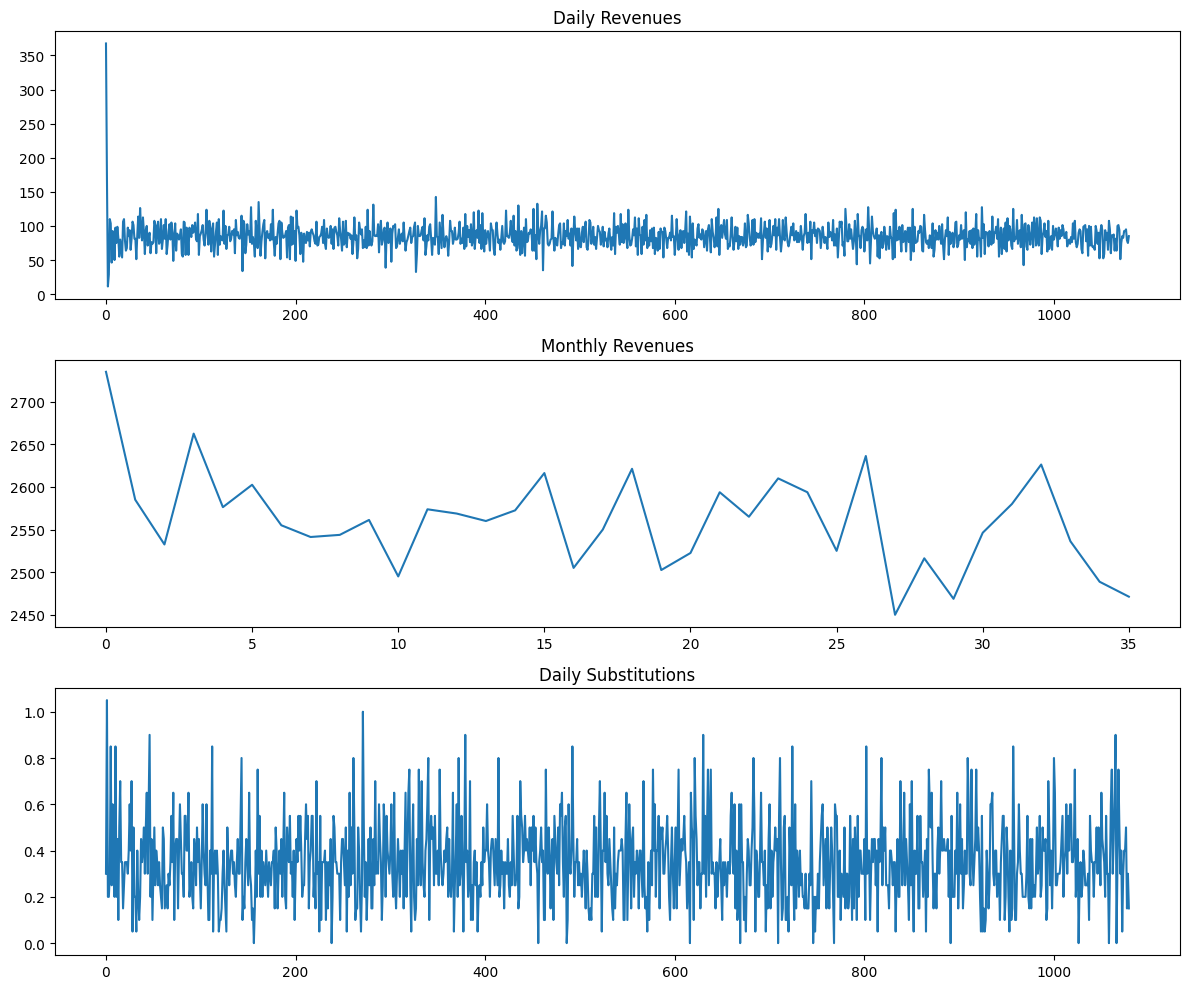

In [10]:
# ============================================================
# 🚗 Rental Company Simulation (Daily Model, 3 Years)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
import os

# --- Simulation Parameters ---
T_months = 36
T_days = T_months * 30
Nsim = 20  #200

# Fleet purchase costs (CAPEX)
B1, B2 = 30000, 20000

# Salvage value parameters
alpha1, alpha2 = 0.6, 0.4
sigma1, sigma2 = 250, 150

# Rental prices per day
P1, P2 = 50.0, 25.0   # "good" car more expensive

# Operating (wholesale) costs per month → convert to per day
W1_month, W2_month = 100.0, 80.0
W1, W2 = W1_month / 30.0, W2_month / 30.0

# Holding costs per day
h1, h2 = 1.0, 1.0

# Substitution cap per day
b_max = 10   # we will vary later

# Rental length distributions (days)
lambda1, lambda2 = 3, 4

# Demand distribution parameters
LAMBDA2_month = 8
LAMBDA2_daily = LAMBDA2_month
#/ 30.0
m = 4

# Discount rate (annual → daily)
r_annual = 0.05
r_daily = (1 + r_annual)**(1/365) - 1

# ============================================================
# Helper Functions
# ============================================================

def simulate_salvage():
    """Random salvage values at horizon (3 years)."""
    eps1 = np.random.normal(0, sigma1)
    eps2 = np.random.normal(0, sigma2)
    return alpha1*B1 + eps1, alpha2*B2 + eps2

def simulate_demands():
    """Draw daily demands D2 ~ Pois, then D1|D2 ~ Pois."""
    D2 = np.random.poisson(LAMBDA2_daily)
    D1 = np.random.poisson(abs(D2 - m) + 1)
    return D1, D2

def simulate_one(Q1, Q2, b, T_days=1080):
    """Simulate one scenario for given fleet sizes and substitution limit b."""
    # availability of cars (day they return)
    avail1 = np.zeros(Q1, dtype=int)
    avail2 = np.zeros(Q2, dtype=int)

    revenues_daily = []
    subs_daily = []

    for day in range(T_days):
        # Count available today
        free1 = np.sum(avail1 <= day)
        free2 = np.sum(avail2 <= day)

        # Draw demands
        D1, D2 = simulate_demands()

        # --- Allocate type 1 customers ---
        rent1 = min(free1, D1)
        free1 -= rent1
        rev = rent1 * P1
        # assign returns
        idx = np.where(avail1 <= day)[0][:rent1]
        for k in idx:
            dur = 1 + np.random.poisson(lambda1)
            avail1[k] = day + dur

        # --- Allocate type 2 customers ---
        rent2 = min(free2, D2)
        free2 -= rent2
        rev += rent2 * P2
        idx = np.where(avail2 <= day)[0][:rent2]
        for k in idx:
            dur = 1 + np.random.poisson(lambda2)
            avail2[k] = day + dur

        # --- Substitution (use type1 for unmet type2) ---
        unmet2 = D2 - rent2
        subs = min(free1, unmet2, b)
        rev += subs * P2
        idx = np.where(avail1 <= day)[0][:subs]
        for k in idx:
            dur = 1 + np.random.poisson(lambda1)
            avail1[k] = day + dur
        free1 -= subs

        # accumulate
        revenues_daily.append(rev - W1*Q1 - W2*Q2 - h1*Q1 - h2*Q2)
        subs_daily.append(subs)

    return np.array(revenues_daily), np.array(subs_daily)


def evaluate_financials(cashflows):
    """Compute NPV, ROI, Payback, IRR for one path."""
    # initial investment
    capex = -(B1*Q1 + B2*Q2)
    salvage1, salvage2 = simulate_salvage()
    salvage_total = salvage1*Q1 + salvage2*Q2

    # cashflow vector
    cf = np.concatenate(([capex], cashflows, [salvage_total]))

    # NPV
    npv = npf.npv(r_daily, cf)

    # ROI
    roi = (np.sum(cf[1:]) / -capex)

    # Payback (discounted)
    cumdisc = np.cumsum(cf / (1+r_daily)**np.arange(len(cf)))
    payback = np.argmax(cumdisc >= 0) if np.any(cumdisc >= 0) else np.nan

    # IRR
    try:
        irr = npf.irr(cf)
    except:
        irr = np.nan

    return npv, roi, payback, irr

# ============================================================
# Grid Simulation
# ============================================================

results = []
results_path = "./results"
os.makedirs(results_path, exist_ok=True)

Qmax = 20

for Q1 in range(5, Qmax+1, 5):
    for Q2 in range(5, Qmax+1, 5):
        npvs, rois, pays, irrs = [], [], [], []
        daily_store, monthly_store, subs_store = [], [], []

        for _ in range(Nsim):
            revenues_daily, subs_daily = simulate_one(Q1, Q2, b_max, T_days)

            # aggregate monthly
            revenues_monthly = revenues_daily.reshape(T_months, 30).sum(axis=1)

            # financial evaluation
            npv, roi, payback, irr = evaluate_financials(revenues_daily)
            npvs.append(npv); rois.append(roi); pays.append(payback); irrs.append(irr)

            daily_store.append(revenues_daily)
            monthly_store.append(revenues_monthly)
            subs_store.append(subs_daily)

        # Save average daily and monthly revenues
        df_daily = pd.DataFrame(np.mean(daily_store, axis=0), columns=["revenue"])
        df_daily.to_csv(os.path.join(results_path, f"revenues_daily_Q{Q1}_{Q2}.csv"))

        df_monthly = pd.DataFrame(np.mean(monthly_store, axis=0), columns=["revenue"])
        df_monthly.to_csv(os.path.join(results_path, f"revenues_monthly_Q{Q1}_{Q2}.csv"))

        df_subs = pd.DataFrame(np.mean(subs_store, axis=0), columns=["substitutions"])
        df_subs.to_csv(os.path.join(results_path, f"subs_daily_Q{Q1}_{Q2}.csv"))

        results.append([Q1, Q2, np.mean(npvs), np.mean(rois), np.nanmean(pays), np.nanmean(irrs)])

# Collect results
df_results = pd.DataFrame(results, columns=["Q1", "Q2", "NPV", "ROI", "Payback", "IRR"])
df_results.to_csv(os.path.join(results_path, "summary_results.csv"), index=False)

# ============================================================
# Visualization
# ============================================================

# Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, metric in zip(axes.ravel(), ["NPV","ROI","Payback","IRR"]):
    #pivot = df_results.pivot("Q2","Q1",metric)
    pivot = df_results.pivot(index="Q2", columns="Q1", values=metric)
    im = ax.imshow(pivot, origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(metric)
    ax.set_xlabel("Q1 (good cars)")
    ax.set_ylabel("Q2 (cheap cars)")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Example time series for one fleet
example_Q1, example_Q2 = 10, 10
daily_rev = pd.read_csv(os.path.join(results_path, f"revenues_daily_Q{example_Q1}_{example_Q2}.csv"))
monthly_rev = pd.read_csv(os.path.join(results_path, f"revenues_monthly_Q{example_Q1}_{example_Q2}.csv"))
subs_daily = pd.read_csv(os.path.join(results_path, f"subs_daily_Q{example_Q1}_{example_Q2}.csv"))

fig, ax = plt.subplots(3,1,figsize=(12,10), sharex=False)
ax[0].plot(daily_rev["revenue"]); ax[0].set_title("Daily Revenues")
ax[1].plot(monthly_rev["revenue"]); ax[1].set_title("Monthly Revenues")
ax[2].plot(subs_daily["substitutions"]); ax[2].set_title("Daily Substitutions")
plt.tight_layout()
plt.show()


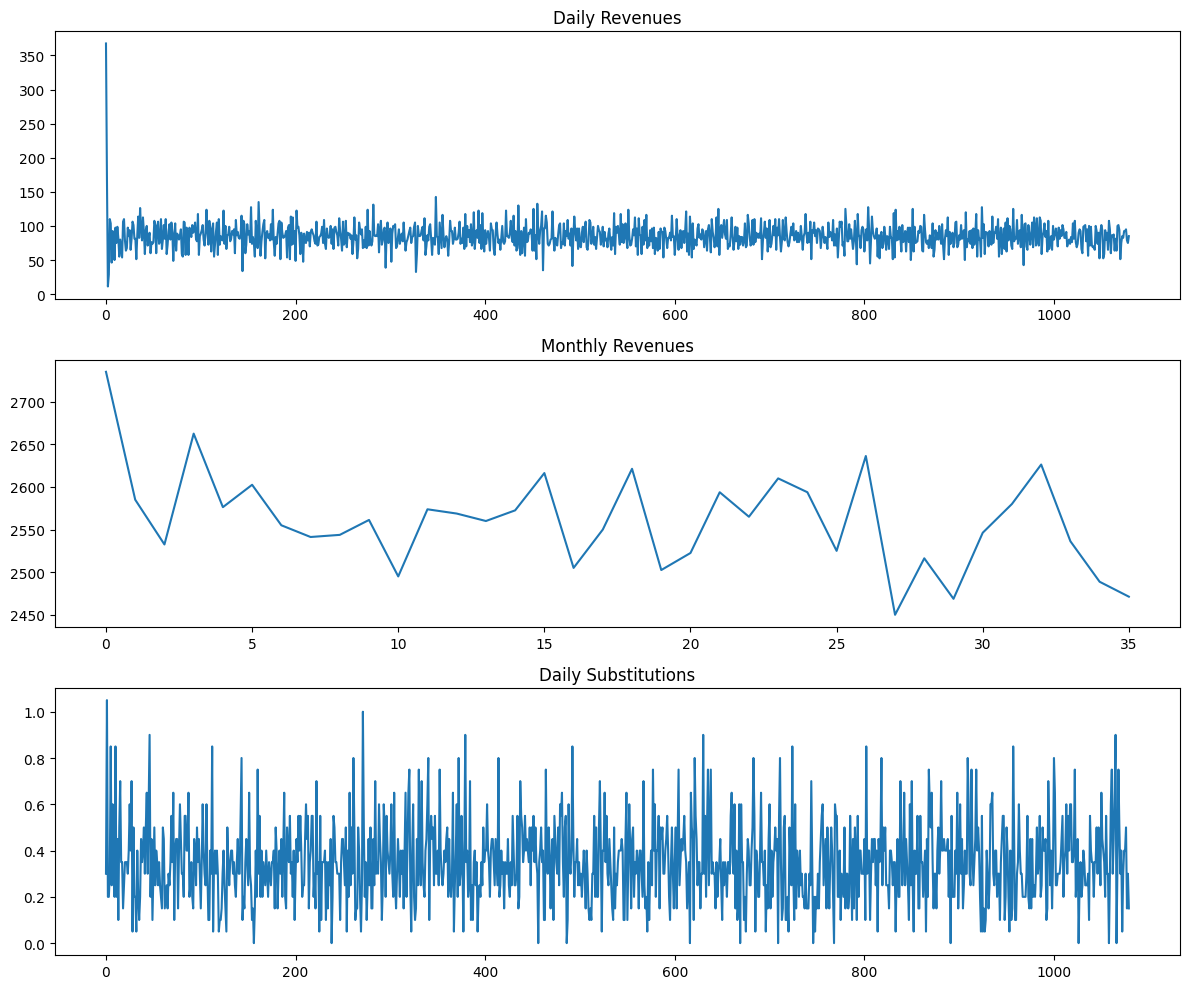

In [11]:
# Example time series for one fleet
example_Q1, example_Q2 = 10, 10
daily_rev = pd.read_csv(os.path.join(results_path, f"revenues_daily_Q{example_Q1}_{example_Q2}.csv"))
monthly_rev = pd.read_csv(os.path.join(results_path, f"revenues_monthly_Q{example_Q1}_{example_Q2}.csv"))
subs_daily = pd.read_csv(os.path.join(results_path, f"subs_daily_Q{example_Q1}_{example_Q2}.csv"))

fig, ax = plt.subplots(3,1,figsize=(12,10), sharex=False)
ax[0].plot(daily_rev["revenue"]); ax[0].set_title("Daily Revenues")
ax[1].plot(monthly_rev["revenue"]); ax[1].set_title("Monthly Revenues")
ax[2].plot(subs_daily["substitutions"]); ax[2].set_title("Daily Substitutions")
plt.tight_layout()
plt.show()

In [ ]:
#############№№№№№№№№№№№№№№№№№№№№№№№№№№№№№№№№№

C:\Users\della\AppData\Local\Temp\ipykernel_57164\2918158866.py:185: RuntimeWarning: Mean of empty slice
  results.append([Q1, Q2, np.mean(npvs), np.mean(rois), np.nanmean(pays), np.nanmean(irrs)])


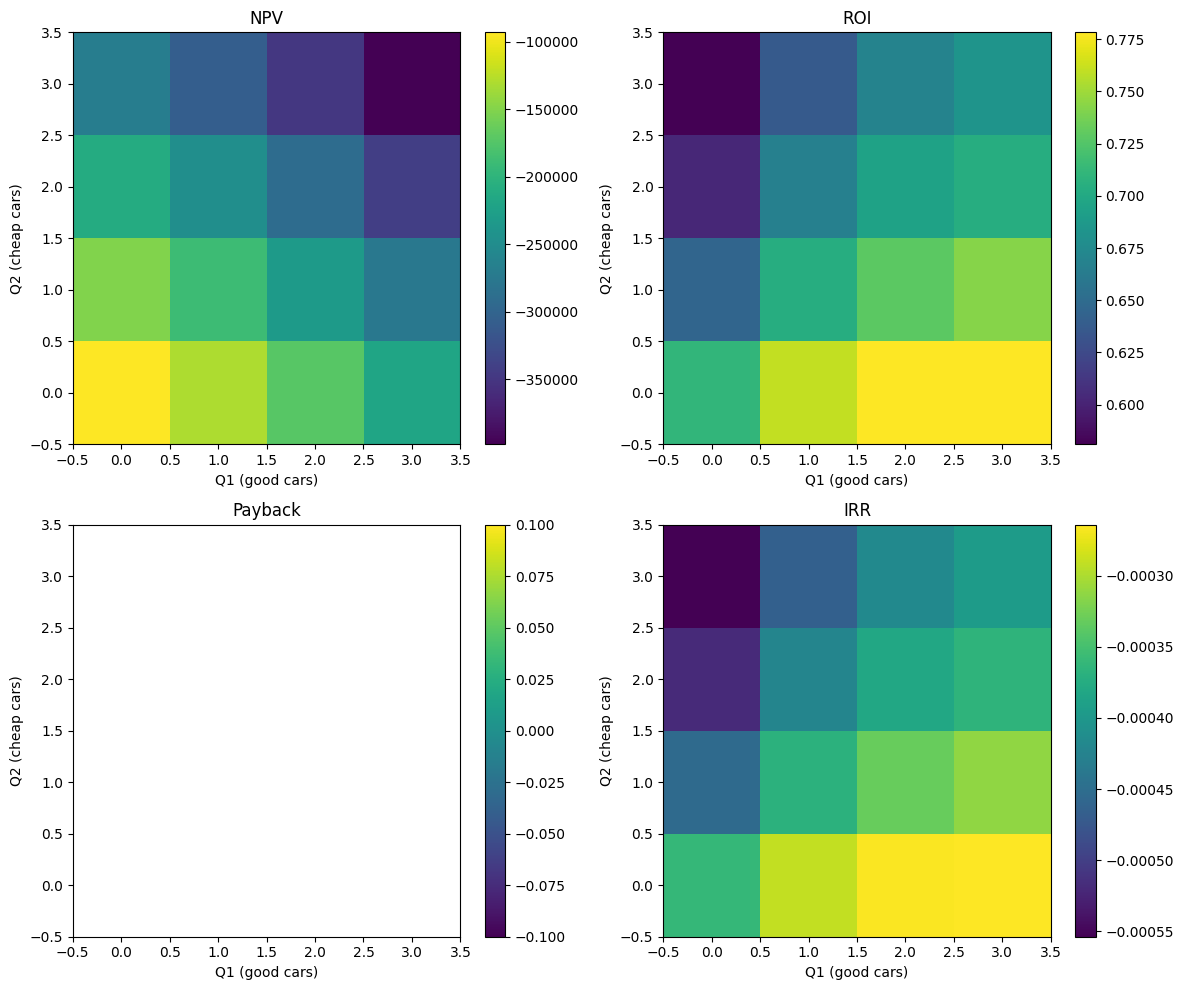

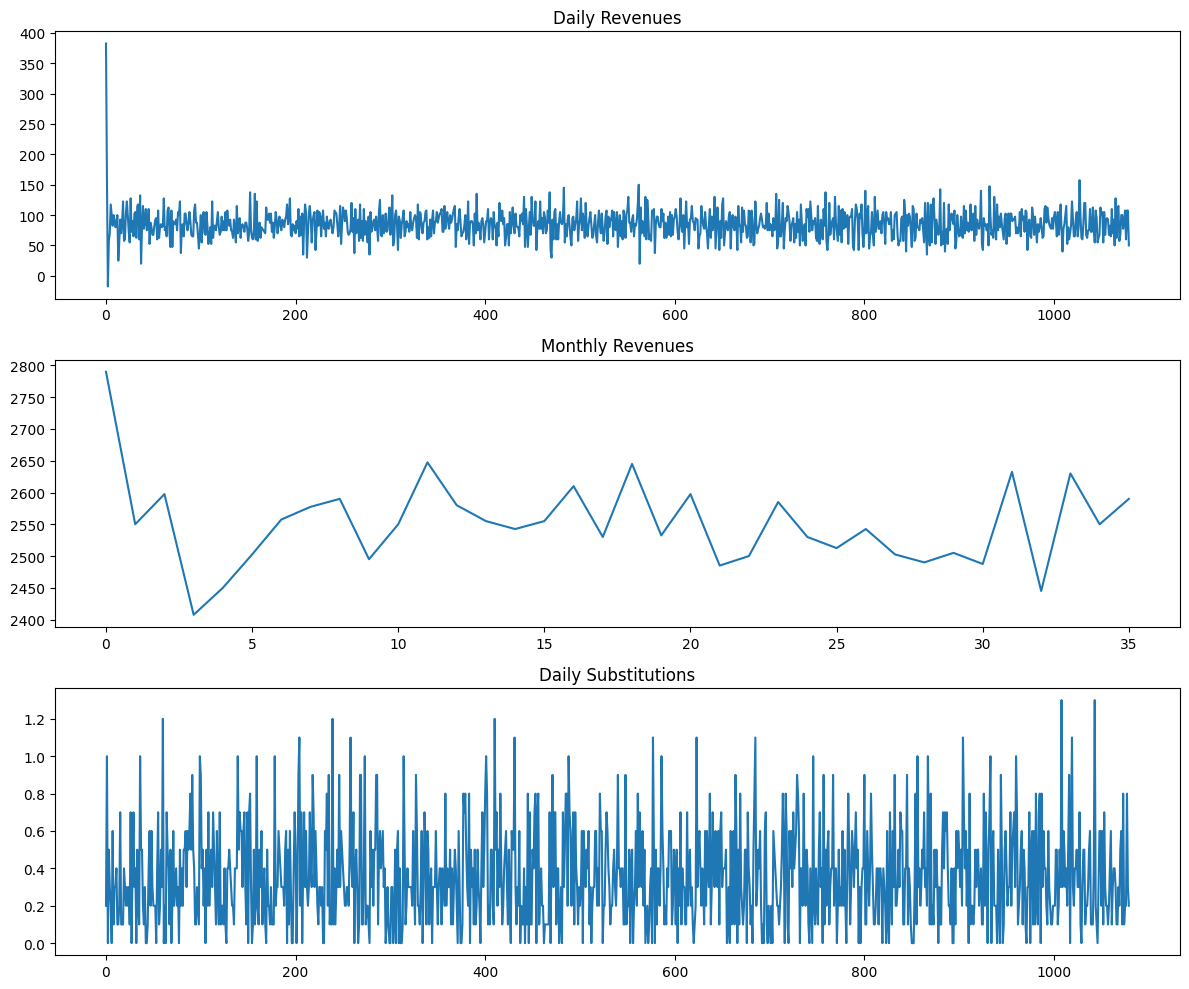

In [12]:
# ============================================================
# 🚗 Rental Company Simulation (Daily Model, 3 Years)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
import os

# --- Simulation Parameters ---
T_months = 36
T_days = T_months * 30
Nsim = 10

# Fleet purchase costs (CAPEX)
B1, B2 = 30000, 20000

# Salvage value parameters
alpha1, alpha2 = 0.6, 0.4
sigma1, sigma2 = 250, 150

# Rental prices per day
P1, P2 = 50.0, 25.0   # "good" car more expensive

# Operating (wholesale) costs per month → convert to per day
W1_month, W2_month = 100.0, 80.0
W1, W2 = W1_month / 30.0, W2_month / 30.0

# Holding costs per day
h1, h2 = 1.0, 1.0

# Substitution cap per day
b_max = 10   # we will vary later

# Rental length distributions (days)
lambda1, lambda2 = 3, 4

# Demand distribution parameters
LAMBDA2_month = 8
LAMBDA2_daily = LAMBDA2_month
#/ 30.0
m = 4

# Discount rate (annual → daily)
r_annual = 0.05
r_daily = (1 + r_annual)**(1/365) - 1

# ============================================================
# Helper Functions
# ============================================================

def simulate_salvage():
    """Random salvage values at horizon (3 years)."""
    eps1 = np.random.normal(0, sigma1)
    eps2 = np.random.normal(0, sigma2)
    return alpha1*B1 + eps1, alpha2*B2 + eps2

def simulate_demands():
    """Draw daily demands D2 ~ Pois, then D1|D2 ~ Pois."""
    D2 = np.random.poisson(LAMBDA2_daily)
    D1 = np.random.poisson(abs(D2 - m) + 1)
    return D1, D2

def simulate_one(Q1, Q2, b, T_days=1080):
    """Simulate one scenario for given fleet sizes and substitution limit b."""
    # availability of cars (day they return)
    avail1 = np.zeros(Q1, dtype=int)
    avail2 = np.zeros(Q2, dtype=int)

    revenues_daily = []
    subs_daily = []

    for day in range(T_days):
        # Count available today
        free1 = np.sum(avail1 <= day)
        free2 = np.sum(avail2 <= day)

        # Draw demands
        D1, D2 = simulate_demands()

        # --- Allocate type 1 customers ---
        rent1 = min(free1, D1)
        free1 -= rent1
        rev = rent1 * P1
        # assign returns
        idx = np.where(avail1 <= day)[0][:rent1]
        for k in idx:
            dur = 1 + np.random.poisson(lambda1)
            avail1[k] = day + dur

        # --- Allocate type 2 customers ---
        rent2 = min(free2, D2)
        free2 -= rent2
        rev += rent2 * P2
        idx = np.where(avail2 <= day)[0][:rent2]
        for k in idx:
            dur = 1 + np.random.poisson(lambda2)
            avail2[k] = day + dur

        # --- Substitution (use type1 for unmet type2) ---
        unmet2 = D2 - rent2
        subs = min(free1, unmet2, b)
        rev += subs * P2
        idx = np.where(avail1 <= day)[0][:subs]
        for k in idx:
            dur = 1 + np.random.poisson(lambda1)
            avail1[k] = day + dur
        free1 -= subs

        # accumulate
        revenues_daily.append(rev - W1*Q1 - W2*Q2 - h1*Q1 - h2*Q2)
        subs_daily.append(subs)

    return np.array(revenues_daily), np.array(subs_daily)


def evaluate_financials(cashflows):
    """Compute NPV, ROI, Payback, IRR for one path."""
    # initial investment
    capex = -(B1*Q1 + B2*Q2)
    salvage1, salvage2 = simulate_salvage()
    salvage_total = salvage1*Q1 + salvage2*Q2

    # cashflow vector
    cf = np.concatenate(([capex], cashflows, [salvage_total]))

    # NPV
    npv = npf.npv(r_daily, cf)

    # ROI
    roi = (np.sum(cf[1:]) / -capex)

    # Payback (discounted)
    cumdisc = np.cumsum(cf / (1+r_daily)**np.arange(len(cf)))
    payback = np.argmax(cumdisc >= 0) if np.any(cumdisc >= 0) else np.nan

    # IRR
    try:
        irr = npf.irr(cf)
    except:
        irr = np.nan

    return npv, roi, payback, irr

# ============================================================
# Grid Simulation
# ============================================================

results = []
results_path = "./results"
os.makedirs(results_path, exist_ok=True)

Qmax = 20

for Q1 in range(5, Qmax+1, 5):
    for Q2 in range(5, Qmax+1, 5):
        npvs, rois, pays, irrs = [], [], [], []
        daily_store, monthly_store, subs_store = [], [], []

        for _ in range(Nsim):
            revenues_daily, subs_daily = simulate_one(Q1, Q2, b_max, T_days)

            # aggregate monthly
            revenues_monthly = revenues_daily.reshape(T_months, 30).sum(axis=1)

            # financial evaluation
            npv, roi, payback, irr = evaluate_financials(revenues_daily)
            npvs.append(npv); rois.append(roi); pays.append(payback); irrs.append(irr)

            daily_store.append(revenues_daily)
            monthly_store.append(revenues_monthly)
            subs_store.append(subs_daily)

        # Save average daily and monthly revenues
        df_daily = pd.DataFrame(np.mean(daily_store, axis=0), columns=["revenue"])
        df_daily.to_csv(os.path.join(results_path, f"revenues_daily_Q{Q1}_{Q2}.csv"))

        df_monthly = pd.DataFrame(np.mean(monthly_store, axis=0), columns=["revenue"])
        df_monthly.to_csv(os.path.join(results_path, f"revenues_monthly_Q{Q1}_{Q2}.csv"))

        df_subs = pd.DataFrame(np.mean(subs_store, axis=0), columns=["substitutions"])
        df_subs.to_csv(os.path.join(results_path, f"subs_daily_Q{Q1}_{Q2}.csv"))

        results.append([Q1, Q2, np.mean(npvs), np.mean(rois), np.nanmean(pays), np.nanmean(irrs)])

# Collect results
df_results = pd.DataFrame(results, columns=["Q1", "Q2", "NPV", "ROI", "Payback", "IRR"])
df_results.to_csv(os.path.join(results_path, "summary_results.csv"), index=False)

# ============================================================
# Visualization
# ============================================================

# Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, metric in zip(axes.ravel(), ["NPV","ROI","Payback","IRR"]):
    #pivot = df_results.pivot("Q2","Q1",metric)
    pivot = df_results.pivot(index="Q2", columns="Q1", values=metric)
    im = ax.imshow(pivot, origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(metric)
    ax.set_xlabel("Q1 (good cars)")
    ax.set_ylabel("Q2 (cheap cars)")
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Example time series for one fleet
example_Q1, example_Q2 = 10, 10
daily_rev = pd.read_csv(os.path.join(results_path, f"revenues_daily_Q{example_Q1}_{example_Q2}.csv"))
monthly_rev = pd.read_csv(os.path.join(results_path, f"revenues_monthly_Q{example_Q1}_{example_Q2}.csv"))
subs_daily = pd.read_csv(os.path.join(results_path, f"subs_daily_Q{example_Q1}_{example_Q2}.csv"))

fig, ax = plt.subplots(3,1,figsize=(12,10), sharex=False)
ax[0].plot(daily_rev["revenue"]); ax[0].set_title("Daily Revenues")
ax[1].plot(monthly_rev["revenue"]); ax[1].set_title("Monthly Revenues")
ax[2].plot(subs_daily["substitutions"]); ax[2].set_title("Daily Substitutions")
plt.tight_layout()
plt.show()


#DOWNSIZING

In [13]:
# fleet_daily_simulation.py
import numpy as np, pandas as pd, math
from numpy.random import default_rng
import matplotlib.pyplot as plt
rng = default_rng(123456)

# PARAMETERS (edit before full run)
days_per_month = 30
T_months = 36
T_days = T_months * days_per_month  # 1080
B1, B2 = 30000.0, 20000.0
alpha1, alpha2 = 0.6, 0.4
sigma1, sigma2 = 250.0, 150.0
lambda1, lambda2 = 3.0, 4.0  # for durations (days)
LAMBDA_2_month = 8.0
#LAMBDA_2_daily = LAMBDA_2_month / days_per_month
LAMBDA_2_daily = LAMBDA_2_month
m = 4
#P1, P2 = 1500.0, 1000.0
P1, P2 = 50.0, 25.0

W1, W2 = 100.0/30, 80.0
h1_month, h2_month = 200.0, 150.0
h1 = h1_month / days_per_month
h2 = h2_month / days_per_month
r_annual = 0.08
r_daily = (1 + r_annual)**(1/365) - 1.0

# Simulation controls (set these for full run)
Q_max = 20      # change to 20 for full run
Q_range = np.arange(0, Q_max+1)
Nsim = 500      # change to 500 for full run
b = 3           # substitution cap per day (you will sweep this as needed)

# Helper functions (duration counts, salvage sampling)
def sample_salvage_sum(Q1, Q2, rng):
    s1 = rng.normal(alpha1 * B1, sigma1, size=Q1).sum() if Q1>0 else 0.0
    s2 = rng.normal(alpha2 * B2, sigma2, size=Q2).sum() if Q2>0 else 0.0
    return s1 + s2

def sample_duration_counts(num_starts, lambda_param, rng):
    if num_starts <= 0:
        return {}
    samp = 1 + rng.poisson(lambda_param, size=num_starts)
    unique, counts = np.unique(samp, return_counts=True)
    return dict(zip(unique, counts))

# Core per-scenario simulator (daily, efficient release-schedule)
def simulate_one_daily(Q1, Q2, b, rng):
    schedule_len = T_days + 60
    release1 = np.zeros(schedule_len, dtype=int)
    release2 = np.zeros(schedule_len, dtype=int)
    occupied1 = 0
    occupied2 = 0
    daily_revenue = np.zeros(T_days)
    for t in range(1, T_days+1):
        free1 = release1[t] if t < schedule_len else 0
        free2 = release2[t] if t < schedule_len else 0
        occupied1 = max(0, occupied1 - free1)
        occupied2 = max(0, occupied2 - free2)
        avail1 = Q1 - occupied1
        avail2 = Q2 - occupied2
        D2 = rng.poisson(LAMBDA_2_daily)
        lam_d1 = abs(int(D2) - m) + 1
        D1 = rng.poisson(lam_d1)
        A1_own = min(D1, avail1)
        A2_own = min(D2, avail2)
        if A1_own > 0:
            dcounts1 = sample_duration_counts(A1_own, lambda1, rng)
            for L, cnt in dcounts1.items():
                release1[t+int(L)] += cnt
            occupied1 += A1_own
        if A2_own > 0:
            dcounts2 = sample_duration_counts(A2_own, lambda2, rng)
            for L, cnt in dcounts2.items():
                release2[t+int(L)] += cnt
            occupied2 += A2_own
        avail1_after = Q1 - occupied1
        unmet2 = max(0, D2 - A2_own)
        Z = min(avail1_after, unmet2, b)
        if Z > 0:
            dcountsZ = sample_duration_counts(Z, lambda1, rng)
            for L, cnt in dcountsZ.items():
                release1[t+int(L)] += cnt
            occupied1 += Z
        revenue = P1 * A1_own + P2 * (A2_own + Z)
        opcost = W1 * (A1_own + Z) + W2 * A2_own
        holdcost = h1 * Q1 + h2 * Q2
        daily_revenue[t-1] = revenue - opcost - holdcost
    salvage_sum = sample_salvage_sum(Q1, Q2, rng)
    return daily_revenue, salvage_sum

# Evaluator (Monte Carlo) that returns scalar metrics and monthly series
def evaluate_Q_pair_daily(Q1, Q2, b, Nsim, rng):
    CAPEX = B1*Q1 + B2*Q2
    npvs=[]; rois=[]; irrs=[]; paybacks=[]
    monthly_acc = np.zeros(T_months)
    for sim in range(Nsim):
        daily_rev, salvage = simulate_one_daily(Q1,Q2,b,rng)
        monthly_rev = daily_rev.reshape(T_months, days_per_month).sum(axis=1)
        monthly_acc += monthly_rev
        monthly_disc = np.array([(1 + r_daily)**(-(d*days_per_month)) for d in range(1, T_months+1)])
        disc_cf = monthly_rev * monthly_disc
        disc_salvage = salvage * (1 + r_daily)**(-(T_days + 1))
        NPV = -CAPEX + disc_cf.sum() + disc_salvage
        npvs.append(NPV)
        present_inflows = disc_cf.sum() + disc_salvage
        rois.append((present_inflows - CAPEX)/CAPEX if CAPEX>0 else np.nan)
        cum = np.cumsum(disc_cf)
        payback = np.nan
        for t_idx in range(T_months):
            if cum[t_idx] >= CAPEX:
                payback = t_idx+1; break
        if np.isnan(payback) and cum[-1] + disc_salvage >= CAPEX:
            payback = T_months+1
        paybacks.append(payback if not np.isnan(payback) else T_months+2)
        cf_series = np.concatenate(([-CAPEX], monthly_rev, [salvage]))
        try:
            irr = np.irr(cf_series)
        except Exception:
            irr = np.nan
        irrs.append(irr)
    return {
        'NPV_mean': np.nanmean(npvs),
        'ROI_mean': np.nanmean(rois),
        'IRR_mean': np.nanmean(irrs),
        'Payback_mean_months': np.nanmean(paybacks),
        'monthly_rev_mean': monthly_acc / Nsim
    }

# MAIN: iterate grid (CAUTION: heavy for large grid & Nsim)
# Example minimal run (uncomment for full run)
# Q_grid = [(q1,q2) for q1 in Q_range for q2 in Q_range]
# results = []
# for q1,q2 in Q_grid:
#     stats = evaluate_Q_pair_daily(q1,q2,b,Nsim,rng)
#     ... save stats, monthly series, export to CSV ...
#
# Recommended: run on a machine with sufficient CPU/RAM, write intermediate results to disk after each grid point.



In [14]:
# fleet_daily_simulation.py
import numpy as np, pandas as pd, math
from numpy.random import default_rng
import matplotlib.pyplot as plt
rng = default_rng(123456)

# PARAMETERS (edit before full run)
days_per_month = 30
T_months = 36
T_days = T_months * days_per_month  # 1080
B1, B2 = 30000.0, 20000.0
alpha1, alpha2 = 0.6, 0.4
sigma1, sigma2 = 250.0, 150.0
lambda1, lambda2 = 3.0, 4.0  # for durations (days)
LAMBDA_2_month = 8.0
#LAMBDA_2_daily = LAMBDA_2_month / days_per_month
LAMBDA_2_daily = LAMBDA_2_month
m = 4
#P1, P2 = 1500.0, 1000.0
P1, P2 = 50.0, 25.0
W1, W2 = 100.0, 80.0
h1_month, h2_month = 200.0, 150.0
h1 = h1_month / days_per_month
h2 = h2_month / days_per_month
r_annual = 0.08
r_daily = (1 + r_annual)**(1/365) - 1.0

# Simulation controls (set these for full run)
Q_max = 20      # change to 20 for full run
Q_range = np.arange(0, Q_max+1)
Nsim = 500      # change to 500 for full run
b = 3           # substitution cap per day (you will sweep this as needed)

# Helper functions (duration counts, salvage sampling)
def sample_salvage_sum(Q1, Q2, rng):
    s1 = rng.normal(alpha1 * B1, sigma1, size=Q1).sum() if Q1>0 else 0.0
    s2 = rng.normal(alpha2 * B2, sigma2, size=Q2).sum() if Q2>0 else 0.0
    return s1 + s2

def sample_duration_counts(num_starts, lambda_param, rng):
    if num_starts <= 0:
        return {}
    samp = 1 + rng.poisson(lambda_param, size=num_starts)
    unique, counts = np.unique(samp, return_counts=True)
    return dict(zip(unique, counts))

# Core per-scenario simulator (daily, efficient release-schedule)
def simulate_one_daily(Q1, Q2, b, rng):
    schedule_len = T_days + 60
    release1 = np.zeros(schedule_len, dtype=int)
    release2 = np.zeros(schedule_len, dtype=int)
    occupied1 = 0
    occupied2 = 0
    daily_revenue = np.zeros(T_days)
    for t in range(1, T_days+1):
        free1 = release1[t] if t < schedule_len else 0
        free2 = release2[t] if t < schedule_len else 0
        occupied1 = max(0, occupied1 - free1)
        occupied2 = max(0, occupied2 - free2)
        avail1 = Q1 - occupied1
        avail2 = Q2 - occupied2
        D2 = rng.poisson(LAMBDA_2_daily)
        lam_d1 = abs(int(D2) - m) + 1
        D1 = rng.poisson(lam_d1)
        A1_own = min(D1, avail1)
        A2_own = min(D2, avail2)
        if A1_own > 0:
            dcounts1 = sample_duration_counts(A1_own, lambda1, rng)
            for L, cnt in dcounts1.items():
                release1[t+int(L)] += cnt
            occupied1 += A1_own
        if A2_own > 0:
            dcounts2 = sample_duration_counts(A2_own, lambda2, rng)
            for L, cnt in dcounts2.items():
                release2[t+int(L)] += cnt
            occupied2 += A2_own
        avail1_after = Q1 - occupied1
        unmet2 = max(0, D2 - A2_own)
        Z = min(avail1_after, unmet2, b)
        if Z > 0:
            dcountsZ = sample_duration_counts(Z, lambda1, rng)
            for L, cnt in dcountsZ.items():
                release1[t+int(L)] += cnt
            occupied1 += Z
        revenue = P1 * A1_own + P2 * (A2_own + Z)
        opcost = W1 * (A1_own + Z) + W2 * A2_own
        holdcost = h1 * Q1 + h2 * Q2
        daily_revenue[t-1] = revenue - opcost - holdcost
    salvage_sum = sample_salvage_sum(Q1, Q2, rng)
    return daily_revenue, salvage_sum

# Evaluator (Monte Carlo) that returns scalar metrics and monthly series
def evaluate_Q_pair_daily(Q1, Q2, b, Nsim, rng):
    CAPEX = B1*Q1 + B2*Q2
    npvs=[]; rois=[]; irrs=[]; paybacks=[]
    monthly_acc = np.zeros(T_months)
    for sim in range(Nsim):
        daily_rev, salvage = simulate_one_daily(Q1,Q2,b,rng)
        monthly_rev = daily_rev.reshape(T_months, days_per_month).sum(axis=1)
        monthly_acc += monthly_rev
        monthly_disc = np.array([(1 + r_daily)**(-(d*days_per_month)) for d in range(1, T_months+1)])
        disc_cf = monthly_rev * monthly_disc
        disc_salvage = salvage * (1 + r_daily)**(-(T_days + 1))
        NPV = -CAPEX + disc_cf.sum() + disc_salvage
        npvs.append(NPV)
        present_inflows = disc_cf.sum() + disc_salvage
        rois.append((present_inflows - CAPEX)/CAPEX if CAPEX>0 else np.nan)
        cum = np.cumsum(disc_cf)
        payback = np.nan
        for t_idx in range(T_months):
            if cum[t_idx] >= CAPEX:
                payback = t_idx+1; break
        if np.isnan(payback) and cum[-1] + disc_salvage >= CAPEX:
            payback = T_months+1
        paybacks.append(payback if not np.isnan(payback) else T_months+2)
        cf_series = np.concatenate(([-CAPEX], monthly_rev, [salvage]))
        try:
            irr = np.irr(cf_series)
        except Exception:
            irr = np.nan
        irrs.append(irr)
    return {
        'NPV_mean': np.nanmean(npvs),
        'ROI_mean': np.nanmean(rois),
        'IRR_mean': np.nanmean(irrs),
        'Payback_mean_months': np.nanmean(paybacks),
        'monthly_rev_mean': monthly_acc / Nsim
    }

# MAIN: iterate grid (CAUTION: heavy for large grid & Nsim)
# Example minimal run (uncomment for full run)
# Q_grid = [(q1,q2) for q1 in Q_range for q2 in Q_range]
# results = []
# for q1,q2 in Q_grid:
#     stats = evaluate_Q_pair_daily(q1,q2,b,Nsim,rng)
#     ... save stats, monthly series, export to CSV ...
#
# Recommended: run on a machine with sufficient CPU/RAM, write intermediate results to disk after each grid point.



#getting results

In [15]:
!pip install numpy-financial



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


NPV=826,854.75, IRR=nan%, ROI=137.46%, Payback=0 мес.


C:\Users\della\AppData\Local\Temp\ipykernel_57164\3011983883.py:8: RuntimeWarning: overflow encountered in scalar power
  return np.sum([cf / (1 + rate) ** t for t, cf in enumerate(cashflows, start=0)])
C:\Users\della\AppData\Local\Temp\ipykernel_57164\3011983883.py:14: RuntimeWarning: overflow encountered in scalar power
  df = np.sum([-t * cf / (1 + rate) ** (t + 1) for t, cf in enumerate(cashflows, start=0)])


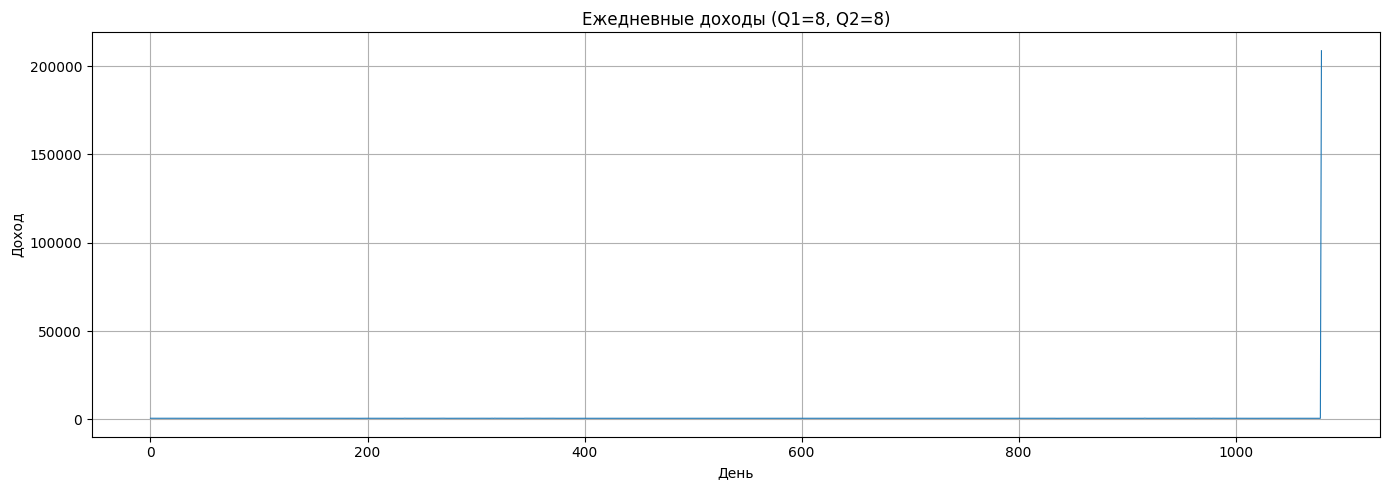

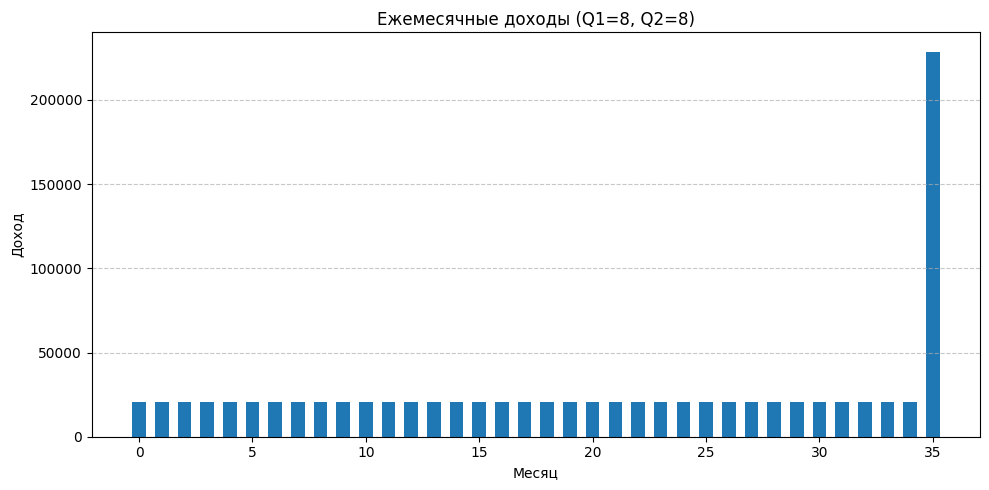

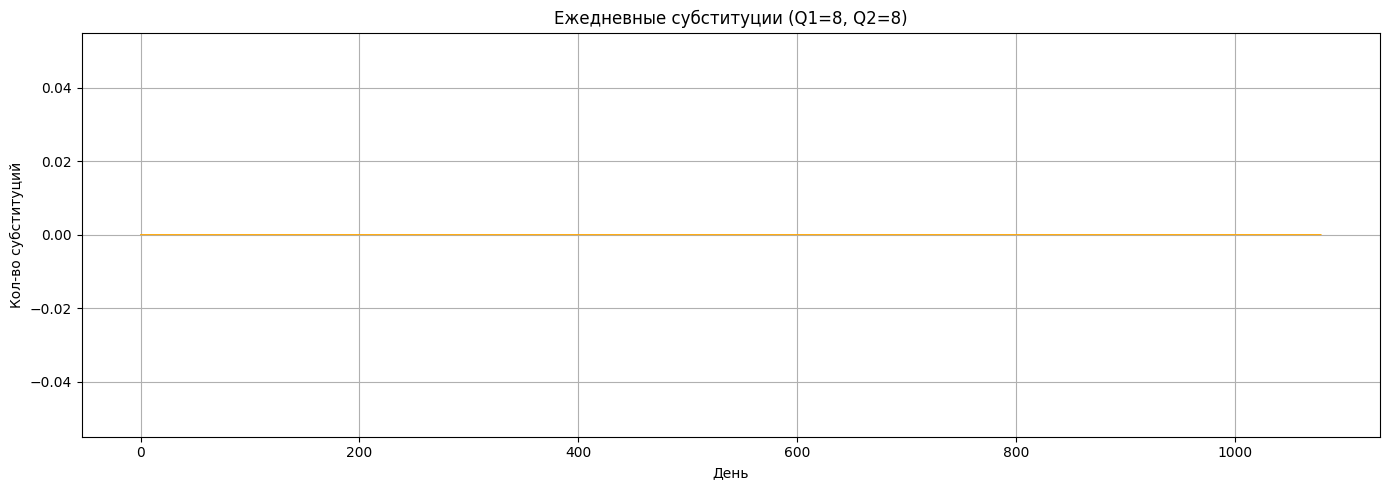

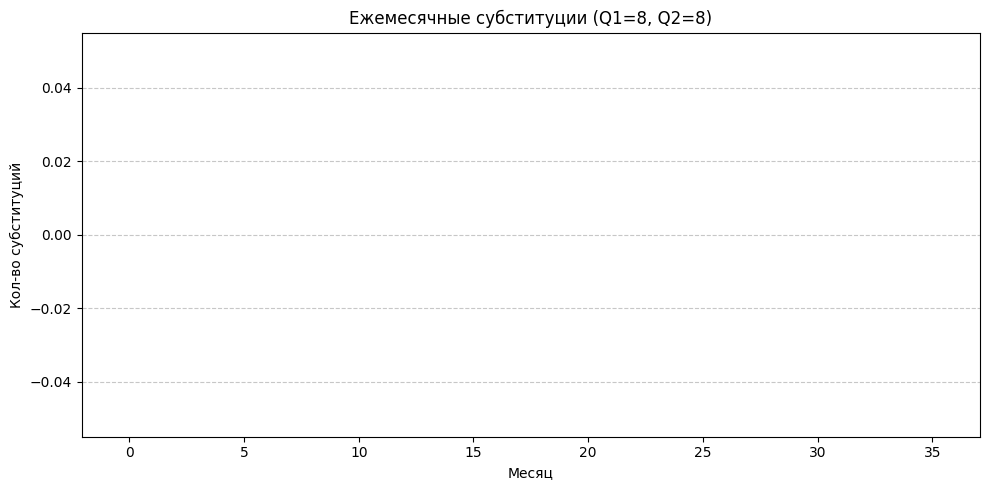

In [ ]:

#not ready yet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- Финансовые функции (без numpy_financial) ---
def npv(rate, cashflows):
    return np.sum([cf / (1 + rate) ** t for t, cf in enumerate(cashflows, start=0)])

def irr(cashflows, guess=0.1, tol=1e-6, max_iter=1000):
    rate = guess
    for _ in range(max_iter):
        f = npv(rate, cashflows)
        df = np.sum([-t * cf / (1 + rate) ** (t + 1) for t, cf in enumerate(cashflows, start=0)])
        if df == 0:
            return np.nan
        new_rate = rate - f / df
        if abs(new_rate - rate) < tol:
            return new_rate
        rate = new_rate
    return np.nan

def payback_period(cashflows, rate=0.0):
    cum = 0
    for t, cf in enumerate(cashflows):
        cum += cf / ((1 + rate) ** t)
        if cum >= 0:
            return t
    return np.inf

# --- Параметры ---
T_days = 1080            # 36 месяцев * 30 дней
B1, B2 = 30000, 20000    # базовые стоимости
alpha1, alpha2 = 0.6, 0.4
sigma1, sigma2 = 50, 100
lambda1, lambda2 = 3, 4  # параметры аренды (длительность в днях)
P1, P2 = 150, 100        # цены аренды
W1, W2 = 5, 3            # условные операционные затраты
h1, h2 = 1, 1            # условные расходы хранения
r = 0.08 / 12            # дисконт (месячный)
b = 5                    # лимит субституций в день
LAMBDA2_month = 8
LAMBDA2_daily = LAMBDA2_month / 30

results_path = "./results"
os.makedirs(results_path, exist_ok=True)

# --- Симуляция для фиксированных Q1, Q2 ---
def simulate(Q1, Q2, Nsim=100):
    revenues_daily = np.zeros(T_days)
    subs_daily = np.zeros(T_days)

    for sim in range(Nsim):
        # генерируем salvage в конце горизонта
        S1 = alpha1 * B1 + np.random.normal(0, sigma1)
        S2 = alpha2 * B2 + np.random.normal(0, sigma2)

        for day in range(T_days):
            # спрос
            D2 = np.random.poisson(LAMBDA2_daily)
            D1 = np.random.poisson(abs(D2 - 4) + 1)

            # доступные машины
            avail1, avail2 = Q1, Q2

            # сначала обслуживаем D1 машинами 1
            served1 = min(avail1, D1)
            revenue_today = served1 * P1
            avail1 -= served1

            # обслуживаем D2 машинами 2
            served2 = min(avail2, D2)
            revenue_today += served2 * P2
            avail2 -= served2

            # downward substitution
            subs_today = min(avail1, D2 - served2, b)
            revenue_today += subs_today * P2
            avail1 -= subs_today

            # расходы
            revenue_today -= served1 * W1 + served2 * W2 + subs_today * W1
            revenue_today -= (avail1 * h1 + avail2 * h2)

            revenues_daily[day] += revenue_today
            subs_daily[day] += subs_today

        # salvage в конце периода
        revenues_daily[-1] += Q1 * S1 + Q2 * S2

    # усредняем
    revenues_daily /= Nsim
    subs_daily /= Nsim
    return revenues_daily, subs_daily

# --- Основной расчёт ---
Q1, Q2 = 8, 8
revenues_daily, subs_daily = simulate(Q1, Q2, Nsim=500)

# --- Аггрегируем по месяцам ---
days_per_month = 30
n_months = T_days // days_per_month
revenues_monthly = revenues_daily.reshape(n_months, days_per_month).sum(axis=1)
subs_monthly = subs_daily.reshape(n_months, days_per_month).sum(axis=1)

# --- Сохраняем CSV ---
df_daily = pd.DataFrame({
    "day": np.arange(T_days),
    "revenue": revenues_daily,
    "substitutions": subs_daily
})
df_daily.to_csv(os.path.join(results_path, f"revenues_daily_Q{Q1}_{Q2}.csv"), index=False)

df_monthly = pd.DataFrame({
    "month": np.arange(n_months),
    "revenue": revenues_monthly,
    "substitutions": subs_monthly
})
df_monthly.to_csv(os.path.join(results_path, f"revenues_monthly_Q{Q1}_{Q2}.csv"), index=False)

# --- Финансовые метрики ---
npv_val = npv(r, revenues_monthly)
irr_val = irr(revenues_monthly)
roi_val = (np.sum(revenues_monthly) - (Q1 * B1 + Q2 * B2)) / (Q1 * B1 + Q2 * B2)
pb_val = payback_period(revenues_monthly, rate=r)

print(f"NPV={npv_val:,.2f}, IRR={irr_val:.2%}, ROI={roi_val:.2%}, Payback={pb_val} мес.")

# --- Графики ---
plt.figure(figsize=(14, 5))
plt.plot(df_daily["day"], df_daily["revenue"], lw=0.8)
plt.title(f"Ежедневные доходы (Q1={Q1}, Q2={Q2})")
plt.xlabel("День"); plt.ylabel("Доход")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(results_path, f"daily_revenue_Q{Q1}_{Q2}.png"))
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df_monthly["month"], df_monthly["revenue"], width=0.6)
plt.title(f"Ежемесячные доходы (Q1={Q1}, Q2={Q2})")
plt.xlabel("Месяц"); plt.ylabel("Доход")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(results_path, f"monthly_revenue_Q{Q1}_{Q2}.png"))
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df_daily["day"], df_daily["substitutions"], lw=0.8, color="orange")
plt.title(f"Ежедневные субституции (Q1={Q1}, Q2={Q2})")
plt.xlabel("День"); plt.ylabel("Кол-во субституций")
plt.grid(True); plt.tight_layout()
plt.savefig(os.path.join(results_path, f"daily_subs_Q{Q1}_{Q2}.png"))
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(df_monthly["month"], df_monthly["substitutions"], width=0.6, color="orange")
plt.title(f"Ежемесячные субституции (Q1={Q1}, Q2={Q2})")
plt.xlabel("Месяц"); plt.ylabel("Кол-во субституций")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(results_path, f"monthly_subs_Q{Q1}_{Q2}.png"))
plt.show()


In [17]:
# Cell 0: install helper package if not present (uncomment if needed in your environment)
# In Databricks you may install via libraries UI instead.
# !pip install numpy_financial tqdm

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.random import default_rng
import multiprocessing as mp
from functools import partial
from tqdm.notebook import tqdm
import numpy_financial as npf   # for IRR


ModuleNotFoundError: No module named 'tqdm'

In [18]:
#Ячейка 1 — настройки модели и параметры (редактируйте здесь)
# Cell 1: Model parameters (edit before running full grid)
# Time
days_per_month = 30
T_months = 36
T_days = T_months * days_per_month  # 1080 days

# Purchase prices (CAPEX)
B1, B2 = 30000.0, 20000.0

# Salvage fractions and noise
alpha1, alpha2 = 0.6, 0.4
sigma1, sigma2 = 50.0, 100.0

# Rental length params (in DAYS)
lambda1, lambda2 = 3.0, 4.0  # L = 1 + Pois(lambda_i)

# Demand process
LAMBDA_2_month = 8.0
# per your instruction: LAMBDA_2_daily = LAMBDA_2_month (use 8 per day)
LAMBDA_2_daily = LAMBDA_2_month
m = 4  # conditional parameter for D1 | D2

# Prices / costs (per-rental revenue and per-rental variable costs)
P1, P2 = 1500.0, 1000.0   # revenue per rental (per start)
W1, W2 = 100.0, 80.0      # variable op cost per rental

# Holding/ownership cost: originally monthly; convert to daily
h1_month, h2_month = 200.0, 150.0
h1 = h1_month / days_per_month
h2 = h2_month / days_per_month

# Financials
r_annual = 0.08
r_daily = (1 + r_annual)**(1/365) - 1.0

# Simulation grid & engine
Q_max = 20       # maximum Q to explore (0..Q_max)
Q_range = np.arange(0, Q_max + 1, 1)

Nsim = 500       # Monte Carlo runs per (Q1,Q2) - heavy; consider lowering for test
b_values = [0,1,3,5,10]  # you said you'll vary b 0..10 - we can loop these or pick one

# Output folder
OUTDIR = './fleet_results'
os.makedirs(OUTDIR, exist_ok=True)

# RNG seed base
SEED_BASE = 20250928


In [19]:
#Ячейка 2 — быстрые/безопасные опции (рекомендуем протестировать)
# Cell 2: Quick test settings (use this for a fast smoke-run)
TEST_MODE = True   # set False for full run
if TEST_MODE:
    Q_max = 8
    Q_range = np.arange(0, Q_max + 1)
    Nsim = 200
    b_values = [3]   # demo single b
    print("TEST MODE ON: Q_max=", Q_max, "Nsim=", Nsim, "b_values=", b_values)
else:
    print("FULL MODE: Q_max=", Q_max, "Nsim=", Nsim, "b_values=", b_values)


TEST MODE ON: Q_max= 8 Nsim= 200 b_values= [3]


In [20]:
#Ячейка 3 — ядро симулятора (включая vectorized release-schedule) — НЕ редактируйте обычно

# Cell 3: Core functions (simulate one scenario, evaluator, helpers)
from collections import defaultdict

def sample_salvage_sum(Q1, Q2, rng):
    """Return total salvage cash for Q1 and Q2 cars (sum of per-car random salvage)."""
    s1 = rng.normal(alpha1 * B1, sigma1, size=Q1).sum() if Q1 > 0 else 0.0
    s2 = rng.normal(alpha2 * B2, sigma2, size=Q2).sum() if Q2 > 0 else 0.0
    return s1 + s2

def sample_duration_counts(num_starts, lambda_param, rng):
    """Return dict {L:count} for durations L = 1 + Pois(lambda)."""
    if num_starts <= 0:
        return {}
    samp = 1 + rng.poisson(lambda_param, size=num_starts)
    unique, counts = np.unique(samp, return_counts=True)
    return dict(zip(unique.astype(int), counts.astype(int)))

def simulate_one_daily(Q1, Q2, b, rng):
    """
    Simulate one scenario for T_days. Return daily revenue array length T_days and salvage_sum.
    Uses release-schedule approach for speed.
    """
    schedule_len = T_days + 366  # margin
    release1 = np.zeros(schedule_len, dtype=int)
    release2 = np.zeros(schedule_len, dtype=int)
    occupied1 = 0
    occupied2 = 0
    daily_revenue = np.zeros(T_days, dtype=float)

    for t in range(1, T_days + 1):
        # free cars scheduled to release today
        if t < schedule_len:
            free1 = release1[t]
            free2 = release2[t]
        else:
            free1 = free2 = 0
        occupied1 = max(0, occupied1 - free1)
        occupied2 = max(0, occupied2 - free2)
        avail1 = Q1 - occupied1
        avail2 = Q2 - occupied2

        # DEMAND (daily)
        D2 = rng.poisson(LAMBDA_2_daily)
        lam_d1 = abs(int(D2) - m) + 1
        D1 = rng.poisson(lam_d1)

        # own starts
        A1_own = min(D1, avail1)
        A2_own = min(D2, avail2)

        if A1_own > 0:
            dcounts1 = sample_duration_counts(A1_own, lambda1, rng)
            for L, cnt in dcounts1.items():
                idx = t + L
                if idx < schedule_len:
                    release1[idx] += cnt
            occupied1 += A1_own

        if A2_own > 0:
            dcounts2 = sample_duration_counts(A2_own, lambda2, rng)
            for L, cnt in dcounts2.items():
                idx = t + L
                if idx < schedule_len:
                    release2[idx] += cnt
            occupied2 += A2_own

        # substitution (downward) limited by b per day
        avail1_after = Q1 - occupied1
        unmet2 = max(0, D2 - A2_own)
        Z = min(avail1_after, unmet2, b)
        if Z > 0:
            dcountsZ = sample_duration_counts(Z, lambda1, rng)
            for L, cnt in dcountsZ.items():
                idx = t + L
                if idx < schedule_len:
                    release1[idx] += cnt
            occupied1 += Z

        # cashflow: charge P2 for substituted rentals (policy)
        revenue = P1 * A1_own + P2 * (A2_own + Z)
        opcost = W1 * (A1_own + Z) + W2 * A2_own
        holdcost = h1 * Q1 + h2 * Q2
        daily_revenue[t - 1] = revenue - opcost - holdcost

    salvage_sum = sample_salvage_sum(Q1, Q2, rng)
    return daily_revenue, salvage_sum

def evaluate_Q_pair_daily(Q1, Q2, b, Nsim, seed_base=0):
    """Monte Carlo evaluation for a single (Q1,Q2,b). Uses independent RNG seeds per sim."""
    CAPEX = B1 * Q1 + B2 * Q2
    npvs = []
    rois = []
    irrs = []
    paybacks = []
    monthly_acc = np.zeros(T_months, dtype=float)

    for sim in range(Nsim):
        # create per-sim RNG deterministically for reproducibility
        ss = seed_base + sim + Q1 * 10000 + Q2 * 1000000 + (b * 7)
        rng = default_rng(ss)
        daily_rev, salvage = simulate_one_daily(Q1, Q2, b, rng)
        # aggregate to months
        monthly_rev = daily_rev.reshape(T_months, days_per_month).sum(axis=1)
        monthly_acc += monthly_rev

        # discount monthly by approximated monthly factor (using daily rate aggregated)
        monthly_disc = np.array([(1 + r_daily)**(- (d * days_per_month)) for d in range(1, T_months + 1)])
        disc_cf = monthly_rev * monthly_disc
        disc_salvage = salvage * (1 + r_daily)**(-(T_days + 1))
        NPV = -CAPEX + disc_cf.sum() + disc_salvage
        npvs.append(NPV)
        present_inflows = disc_cf.sum() + disc_salvage
        rois.append((present_inflows - CAPEX) / CAPEX if CAPEX > 0 else np.nan)

        cum = np.cumsum(disc_cf)
        payback = np.nan
        for t_idx in range(T_months):
            if cum[t_idx] >= CAPEX:
                payback = t_idx + 1
                break
        if np.isnan(payback) and cum[-1] + disc_salvage >= CAPEX:
            payback = T_months + 1
        paybacks.append(payback if not np.isnan(payback) else T_months + 2)

        # IRR computed on monthly series (undiscounted CFs)
        cf_series = np.concatenate(([-CAPEX], monthly_rev, [salvage]))
        try:
            irr = npf.irr(cf_series)
        except Exception:
            irr = np.nan
        irrs.append(irr)

    # results: means across sims
    return {
        'Q1': Q1, 'Q2': Q2, 'b': b,
        'NPV_mean': float(np.nanmean(npvs)),
        'ROI_mean': float(np.nanmean(rois)),
        'IRR_mean': float(np.nanmean(irrs)),
        'Payback_mean_months': float(np.nanmean(paybacks)),
        'monthly_rev_mean': (monthly_acc / Nsim).tolist()
    }


In [22]:
#Ячейка 4 — параллельный прогон по сетке и сохранение результатов (в CSVs + PNG)

# Cell 4: Run grid (parallel) and save results. This is the heavy cell.
# Adjust `n_workers` per your environment (number of CPU cores available).
from functools import partial
import json
import time
import os

n_workers = max(1, mp.cpu_count() - 1)  # leave one core free
print("Using n_workers =", n_workers)

def worker_task(args):
    Q1, Q2, b, Nsim, seed = args
    return evaluate_Q_pair_daily(Q1, Q2, b, Nsim, seed)

# prepare tasks: iterate over b_values too (we save separate outputs per b)
all_results = []
start_time = time.time()
for b in b_values:
    tasks = []
    for Q1 in Q_range:
        for Q2 in Q_range:
            tasks.append((int(Q1), int(Q2), int(b), int(Nsim), SEED_BASE))
    print(f"Starting runs for b={b} with {len(tasks)} tasks")
    ###########????????
    #import os

    results_path = "./results"
    os.makedirs(results_path, exist_ok=True)

    # --- Сохраняем ежедневные доходы ---
    df_daily = pd.DataFrame({
     "day": np.arange(len(revenues_daily)),
    "revenue": revenues_daily })
    df_daily.to_csv(os.path.join(results_path, f"revenues_daily_Q{Q1}_{Q2}.csv"), index=False)

    # --- Сохраняем ежемесячные доходы ---
    df_monthly = pd.DataFrame({
    "month": np.arange(len(revenues_monthly)),
    "revenue": revenues_monthly
    })
    df_monthly.to_csv(os.path.join(results_path, f"revenues_monthly_Q{Q1}_{Q2}.csv"), index=False)


    #########
    # parallel map
    with mp.Pool(processes=n_workers) as pool:
        for res in tqdm(pool.imap_unordered(worker_task, tasks), total=len(tasks)):
            # res is dict with monthly_rev_mean (list)
            all_results.append(res)
            # save monthly CSV for this pair (optionally)
            q1 = res['Q1']; q2 = res['Q2']
            monthly = np.array(res['monthly_rev_mean'])
            # save monthly and daily? we save monthly to reduce disk usage
            fname_mon = os.path.join(OUTDIR, f"revenues_monthly_Q{q1}_Q{q2}_b{b}.csv")
            pd.DataFrame({'month': np.arange(1, T_months + 1), 'monthly_rev_mean': monthly}).to_csv(fname_mon, index=False)
    # after each b, save summary for that b
    df_b = pd.DataFrame([r for r in all_results if r['b'] == b])
    # expand monthly_rev_mean into a JSON string to keep dataframe compact; main summary separate
    df_summary = df_b[['Q1','Q2','b','NPV_mean','ROI_mean','IRR_mean','Payback_mean_months']].copy()
    summary_fname = os.path.join(OUTDIR, f"results_summary_b{b}.csv")
    df_summary.to_csv(summary_fname, index=False)
    # heatmap for NPV
    pivot = df_summary.pivot(index='Q1', columns='Q2', values='NPV_mean')
    plt.figure(figsize=(8,6))
    plt.pcolormesh(pivot.columns.values, pivot.index.values, pivot.values, shading='auto')
    plt.colorbar(label='Expected NPV')
    plt.xlabel('Q2')
    plt.ylabel('Q1')
    plt.title(f'Expected NPV (b={b})')
    heatmap_fname = os.path.join(OUTDIR, f'npv_heatmap_b{b}.png')
    plt.savefig(heatmap_fname, dpi=150)
    plt.close()
end_time = time.time()
print("All runs finished in", round((end_time - start_time)/60,2), "minutes")


Using n_workers = 21
Starting runs for b=3 with 81 tasks


NameError: name 'tqdm' is not defined

In [23]:
#Ячейка 5 — пример чтения результатов и отображения (после завершения)
# Cell 5: Example: load summary for a particular b and show top results and heatmap inline
b = b_values[0]
summary_path = os.path.join(OUTDIR, f"results_summary_b{b}.csv")
if os.path.exists(summary_path):
    df = pd.read_csv(summary_path)
    display(df.sort_values('NPV_mean', ascending=False).head(10))
    from IPython.display import Image, display
    img_path = os.path.join(OUTDIR, f'npv_heatmap_b{b}.png')
    if os.path.exists(img_path):
        display(Image(filename=img_path))
else:
    print("Summary not found — run the previous cell first.")


Summary not found — run the previous cell first.


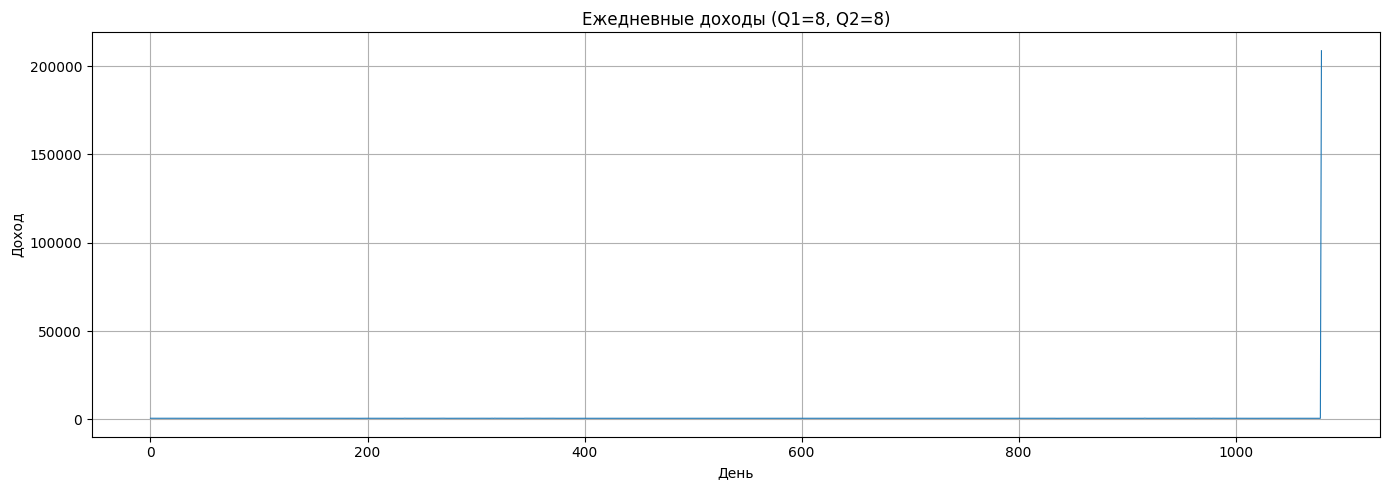

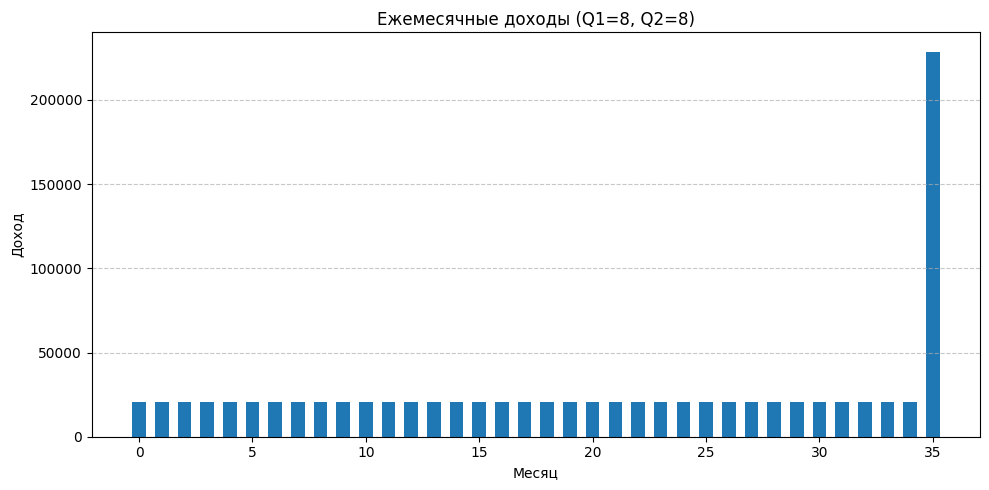

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# === Параметры выбора сценария ===
Q1, Q2 = 8, 8  # <-- подставь нужные значения
results_path = "./results"  # папка, где сохранялись файлы симуляции

# === Файлы с доходами ===
file_daily = os.path.join(results_path, f"revenues_daily_Q{Q1}_{Q2}.csv")
file_monthly = os.path.join(results_path, f"revenues_monthly_Q{Q1}_{Q2}.csv")

# === Чтение данных ===
df_daily = pd.read_csv(file_daily)
df_monthly = pd.read_csv(file_monthly)

# === График: ежедневные доходы ===
plt.figure(figsize=(14, 5))
plt.plot(df_daily["day"], df_daily["revenue"], lw=0.8)
plt.title(f"Ежедневные доходы (Q1={Q1}, Q2={Q2})")
plt.xlabel("День")
plt.ylabel("Доход")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_path, f"daily_revenue_Q{Q1}_{Q2}.png"))
plt.show()

# === График: ежемесячные доходы ===
plt.figure(figsize=(10, 5))
plt.bar(df_monthly["month"], df_monthly["revenue"], width=0.6)
plt.title(f"Ежемесячные доходы (Q1={Q1}, Q2={Q2})")
plt.xlabel("Месяц")
plt.ylabel("Доход")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(results_path, f"monthly_revenue_Q{Q1}_{Q2}.png"))
plt.show()
